<a href="https://colab.research.google.com/github/FLoscode/Axion/blob/main/Algotrading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import psutil

# Get CPU usage percentage
print(f"CPU Usage: {psutil.cpu_percent()}%")

# Get RAM details
ram = psutil.virtual_memory()
print(f"Total RAM: {ram.total / (1024**3):.2f} GB")
print(f"Available RAM: {ram.available / (1024**3):.2f} GB")
print(f"Used RAM: {ram.used / (1024**3):.2f} GB")
print(f"RAM Usage: {ram.percent}%")


CPU Usage: 21.4%
Total RAM: 15.65 GB
Available RAM: 3.43 GB
Used RAM: 12.21 GB
RAM Usage: 78.1%


Pair Trading strategy - GDX and GLD

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm

def backtest_pairs_trading(ticker1="GLD", ticker2="GDX", lookback=60):
    # 1. Data Ingestion
    data = yf.download([ticker1, ticker2], start="2023-01-01")['Close']
    data = np.log(data).dropna() # Log prices for percentage-based stationarity

    # 2. Spread Calculation using OLS (Linear Algebra Lesson 15)
    # We find the Beta (Hedge Ratio) that makes the spread stationary
    y = data[ticker1]
    x = sm.add_constant(data[ticker2])
    model = sm.OLS(y, x).fit()
    beta = model.params[ticker2]

    # Calculate Spread
    data['spread'] = data[ticker1] - (beta * data[ticker2])

    # 3. Z-Score Normalization (Probability Lesson 7)
    data['mean'] = data['spread'].rolling(window=lookback).mean()
    data['std'] = data['spread'].rolling(window=lookback).std()
    data['z_score'] = (data['spread'] - data['mean']) / data['std']

    # 4. Signal Logic
    data['signal'] = 0
    data.loc[data['z_score'] > 2, 'signal'] = -1  # Short Ticker1, Long Ticker2
    data.loc[data['z_score'] < -2, 'signal'] = 1  # Long Ticker1, Short Ticker2
    data.loc[abs(data['z_score']) < 0.5, 'signal'] = 0 # Exit at Mean

    return data.dropna()

# Execute
results = backtest_pairs_trading()
print(results[['z_score', 'signal']].tail(10))

[*********************100%***********************]  2 of 2 completed

Ticker       z_score  signal
Date                        
2026-07-10  0.697165       0
2026-07-13  0.364513       0
2026-07-14  0.288131       0
2026-07-15  0.760783       0
2026-07-16  1.042573       0
2026-07-17  1.553541       0
2026-07-20  1.680115       0
2026-07-21  0.862588       0
2026-07-22  0.191125       0
2026-07-23 -0.075675       0


Simple Mean reverting strategy.

[*********************100%***********************]  1 of 1 completed


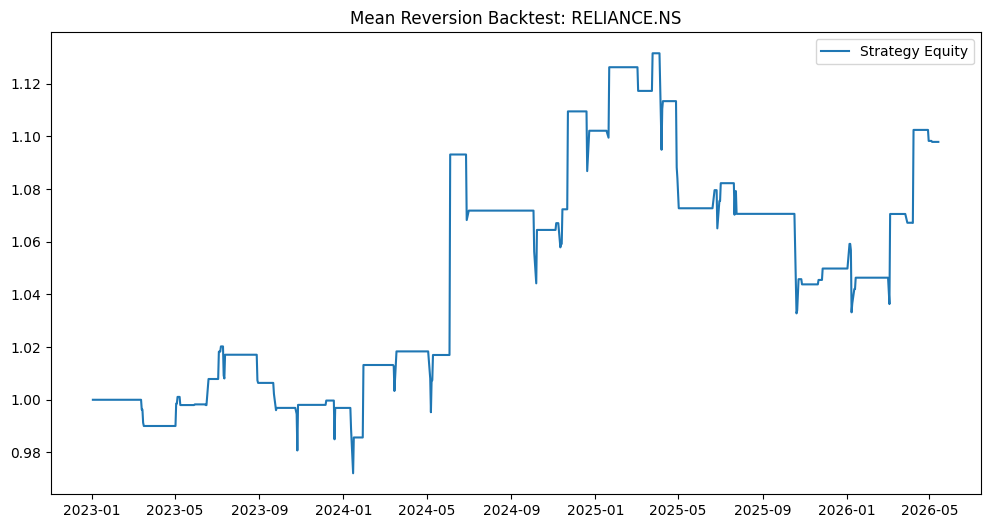

Annualized Sharpe Ratio: 0.40
Maximum Drawdown: -8.73%


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Ingestion: Download data for a high-beta stock
ticker = "RELIANCE.NS" # Example: Reliance Industries (India)
downloaded_data = yf.download(ticker, start="2023-01-01", end="2026-05-15")

# Ensure 'Close' price is a single Series, handling potential MultiIndex or flat index from yfinance
# and then create a new DataFrame 'data' with a single 'Close' column.
if isinstance(downloaded_data.columns, pd.MultiIndex):
    # This assumes the close price is under ('Close', ticker) for MultiIndex columns
    close_series = downloaded_data['Close'][ticker]
else:
    # This assumes the close price is under 'Close' for flat columns
    close_series = downloaded_data['Close']

data = pd.DataFrame({'Close': close_series})

# 2. Calculate Mean (μ) and Std Dev (σ)
window = 20 # 20-day lookback
data['mu'] = data['Close'].rolling(window=window).mean()
data['sigma'] = data['Close'].rolling(window=window).std()

# 3. Z-Score: The "Spring" Tension
data['z_score'] = (data['Close'] - data['mu']) / data['sigma']

# 4. Signal Logic (Fixed Rules)
data['signal'] = 0
data.loc[data['z_score'] < -2, 'signal'] = 1  # Buy (Oversold)
data.loc[data['z_score'] > 2, 'signal'] = -1  # Sell (Overbought)
data.loc[abs(data['z_score']) < 0.5, 'signal'] = 0 # Exit at Mean

# 5. Returns: No Transaction Costs (As requested)
data['returns'] = data['Close'].pct_change()
data['strategy_returns'] = data['signal'].shift(1) * data['returns']
data['equity_curve'] = (1 + data['strategy_returns'].fillna(0)).cumprod()

# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(data['equity_curve'], label='Strategy Equity')
plt.title(f"Mean Reversion Backtest: {ticker}")
plt.legend()
plt.show()

# Performance Summary
sharpe = (data['strategy_returns'].mean() / data['strategy_returns'].std()) * np.sqrt(252)
mdd = (data['equity_curve'] / data['equity_curve'].cummax() - 1).min()
print(f"Annualized Sharpe Ratio: {sharpe:.2f}")
print(f"Maximum Drawdown: {mdd:.2%}")

Small variations in the Mean trading strategy.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# 1. Setup Data
ticker = "RELIANCE.NS"
downloaded_data = yf.download(ticker, start="2024-01-01", end="2026-05-15")

# Ensure 'Close' price is a single Series, handling potential MultiIndex or flat index from yfinance
# and then create a new DataFrame 'data' with a single 'Close' column.
if isinstance(downloaded_data.columns, pd.MultiIndex):
    # This assumes the close price is under ('Close', ticker) for MultiIndex columns
    close_series = downloaded_data['Close'][ticker]
else:
    # This assumes the close price is under 'Close' for flat columns
    close_series = downloaded_data['Close']

data = pd.DataFrame({'Close': close_series})

# 2. Strategy Logic (Calculus-based Mean Reversion)
window = 20
data['mu'] = data['Close'].rolling(window=window).mean()
data['sigma'] = data['Close'].rolling(window=window).std()
data['z_score'] = (data['Close'] - data['mu']) / data['sigma'] # [cite: 113]

data['signal'] = 0
data.loc[data['z_score'] < -3, 'signal'] = 1  # Buy signal
data.loc[data['z_score'] > 3, 'signal'] = -1  # Sell signal
data.loc[abs(data['z_score']) < 0.7, 'signal'] = 0 # Exit signal

# 3. Calculate Strategy Returns
data['returns'] = data['Close'].pct_change()
data['strategy_returns'] = data['signal'].shift(1) * data['returns']

# 4. ADD FRICTION (The Variation)
# 0.2% total friction per side (Includes Brokerage + Taxes + Slippage)
cost_per_side = 0.002

# Identify where the signal changes (Entry or Exit)
data['trade_occurred'] = data['signal'].diff().fillna(0).abs() != 0
data['net_returns'] = data['strategy_returns'] - (data['trade_occurred'] * cost_per_side)

# 5. Equity Curve Construction
data['gross_equity'] = (1 + data['strategy_returns'].fillna(0)).cumprod()
data['net_equity'] = (1 + data['net_returns'].fillna(0)).cumprod()

# Result comparison
print(f"Final Gross Equity (No Costs): {data['gross_equity'].iloc[-1]:.2f}")
print(f"Final Net Equity (With Costs): {data['net_equity'].iloc[-1]:.2f}")

[*********************100%***********************]  1 of 1 completed

Final Gross Equity (No Costs): 1.00
Final Net Equity (With Costs): 1.00


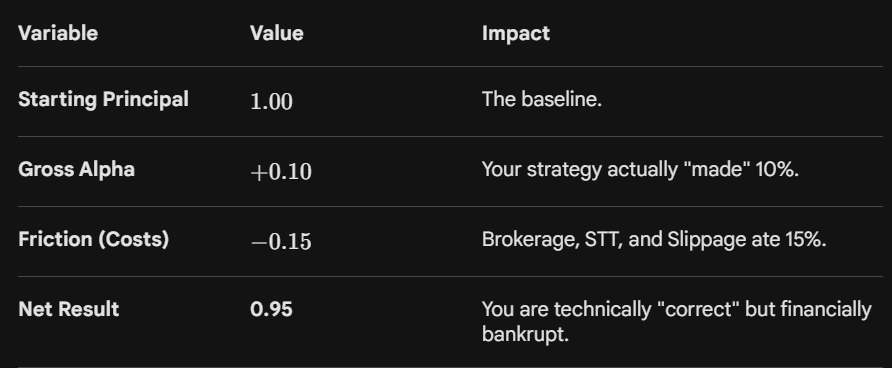

# Streamlit Interactive

In [ ]:
pip install streamlit matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 50.0 MB/s eta 0:00:00


2026-07-23 18:39:47.489 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 18:39:47.802 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-23 18:39:47.803 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 18:39:47.804 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 18:39:47.807 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 18:39:47.807 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 18:39:47.809 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 18:39:47.810 Thread 'MainThread': mi

DeltaGenerator()

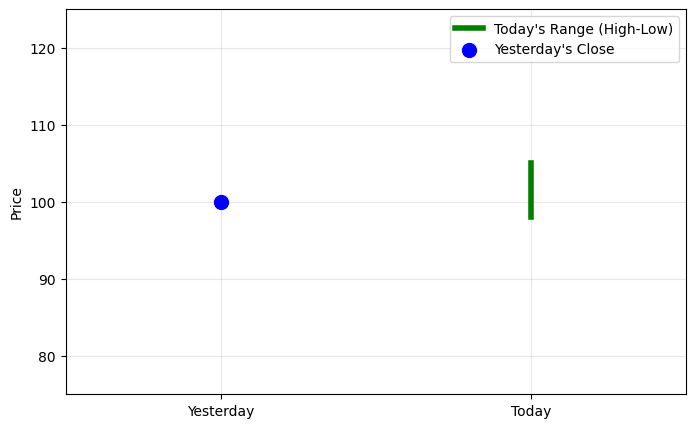

In [ ]:
import streamlit as st
import matplotlib.pyplot as plt
import numpy as np

# 1. UI INGESTION LAYER (The Sliders)
st.title("True Range (TR) Physics Visualizer")

col1, col2, col3 = st.columns(3)
with col1:
    c_prev = st.slider("Yesterday's Close", 80, 120, 100)
with col2:
    h = st.slider("Today's High", 80, 120, 105)
with col3:
    # Floor the low slider to never exceed the high slider
    l = st.slider("Today's Low", 80, h, 98)

# 2. THE LOGIC LAB (Calculations)
dist_a = h - l
dist_b = abs(h - c_prev)
dist_c = abs(l - c_prev)

tr = max(dist_a, dist_b, dist_c)

# 3. VISUAL TERMINAL (Matplotlib rendering)
fig, ax = plt.subplots(figsize=(8, 5))

# Plotting the structural price points
ax.plot([1, 1], [l, h], color='green', linewidth=4, label="Today's Range (High-Low)")
ax.scatter([0], [c_prev], color='blue', s=100, label="Yesterday's Close", zorder=5)

# Visualizing the Gap (The True Range extension)
if c_prev > h:
    ax.plot([0, 1], [c_prev, h], color='red', linestyle='--', label="Gap Down Extension")
elif c_prev < l:
    ax.plot([0, 1], [c_prev, l], color='red', linestyle='--', label="Gap Up Extension")

# Chart Formatting
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(75, 125)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Yesterday', 'Today'])
ax.set_ylabel("Price")
ax.grid(True, alpha=0.3)
ax.legend()

# 4. OUTPUT GATE
st.pyplot(fig)

st.subheader("Mathematical Output")
st.markdown(f"**Distance A (High - Low):** {dist_a}")
st.markdown(f"**Distance B (|High - Prev Close|):** {dist_b}")
st.markdown(f"**Distance C (|Low - Prev Close|):** {dist_c}")
st.error(f"**Calculated True Range (Maximum): {tr}**")

In [ ]:
!streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py

/bin/bash: line 1: streamlit: command not found


# New Market Algorithmic.

In [ ]:
!pip install yfinance
import yfinance as yf
import pandas as pd

# Target ITC on the NSE
data = yf.download("HAL.NS", period="2y", interval="1d")
# Alternatively: yf.download("TATASTEEL.NS", period="2y", interval="1d")

# Preserve data integrity by cleaning multi-index columns
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)
data.rename(columns={'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close', 'Volume': 'volume'}, inplace=True)
data = data.dropna()

print(data.tail())

/tmp/ipykernel_2333/1675348562.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("HAL.NS", period="2y", interval="1d")
[*********************100%***********************]  1 of 1 completed

Price             close         high          low         open   volume
Date                                                                   
2026-06-15  4284.700195  4344.000000  4202.600098  4235.000000  1049980
2026-06-16  4255.799805  4314.700195  4240.500000  4299.799805   584663
2026-06-17  4460.500000  4485.000000  4270.000000  4276.500000  1421845
2026-06-18  4411.500000  4480.500000  4386.500000  4476.000000   851920
2026-06-19  4408.100098  4435.600098  4385.700195  4411.500000   834524


# The New Market Algo (V1)

In [ ]:
# Version 2.
import yfinance as yf
data = yf.download("ITC.NS", period="5y", interval="5d")

import pandas as pd

def check_portfolio_kill_switch(current_equity: float, peak_equity: float) -> bool:
    """
    A. PORTFOLIO KILL SWITCH
    Calculates total account drawdown from its peak.
    Returns True to kill the system if drawdown exceeds 15%, otherwise False.
    Equation: DD = (Epeak - Ex) / Epeak
    """
    drawdown = (peak_equity - current_equity) / peak_equity
    return drawdown > 0.15

def calculate_true_range(high: float, low: float, prev_close: float) -> float:
    """
    B. Position Sizing (True Range)
    Calculates the maximum of the three absolute physical price distances.
    Equation: TR = max(High-Low, |High-Close_prev|, |Low-Close_prev|)
    """
    return max(high - low, abs(high - prev_close), abs(low - prev_close))

def calculate_atr_14(df: pd.DataFrame) -> pd.Series:
    """
    B. Position Sizing (Average True Range)
    Calculates the 14-period average of the True Range.
    Equation: ATR_14 = (1/14) * sum(TR_i)
    """
    prev_close = df['close'].shift(1)
    tr1 = df['high'] - df['low']
    tr2 = (df['high'] - prev_close).abs()
    tr3 = (df['low'] - prev_close).abs()

    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return true_range.rolling(window=14).mean()

def calculate_stop_loss(entry_price: float, atr_14: float) -> float:
    """
    C. Stop Loss
    Sets the stop loss 2 ATRs below the entry price to provide room to breathe.
    Equation: P_stop = P_entry - (2 * ATR_14)
    """
    return entry_price - (2 * atr_14)

def calculate_take_profit(entry_price: float, stop_loss: float) -> float:
    """
    Rule 3: Take Profit
    Calculates the profit target based strictly on the provided document equation.
    Equation: P_target = P_entry + (2.5 * P_entry - P_stop)
    """
    return entry_price + 2.5 * (entry_price - stop_loss)

def calculate_position_cap(current_equity: float) -> float:
    """
    C. Maximum Position Cap
    Caps the maximum capital allocation for a single asset to 20% of total equity.
    Equation: Capital_allocation = 0.20 * E_t
    """
    return 0.20 * current_equity

def generate_sma(series: pd.Series, period: int = 10) -> pd.Series:
    """
    Layer 2 - Simple Moving Average
    Calculates the Simple Moving Average over a specified period.
    Equation: P_10 = (1/T) * sum(P_i)
    """
    return series.rolling(window=period).mean()

def generate_ema(series: pd.Series, period: int) -> pd.Series:
    """
    Layer 2 - Exponential Moving Average
    Calculates the EMA based on the architectural requirement (Based On SMA).
    """
    return series.ewm(span=period, adjust=False).mean()

def generate_system_log(event_data: str):
    """
    System Log and Diagnosis Report
    Fulfills the structural requirement to output a system log.
    """
    print(f"SYSTEM LOG: {event_data}")


[*********************100%***********************]  1 of 1 completed


# ALGO5-6-TFSRT (V2)

In [ ]:
# ===============================================================
#   UNIVERSAL BACKTEST ENGINE
#   Version  : V2 (Full Attribution)
#   Author   : Loki — ALGO Project
#   Use      : Plug any signal function in at the bottom.
#              Works on any asset class yfinance supports.
# ================================================================

import yfinance  as yf
import pandas    as pd
import numpy     as np
import warnings
warnings.filterwarnings("ignore")

# ── ARCHITECTURAL FUNCTIONS ─────────────────────────────────────
def generate_sma(series: pd.Series, period: int = 10) -> pd.Series:
    return series.rolling(window=period).mean()

def generate_ema(series: pd.Series, period: int) -> pd.Series:
    return series.ewm(span=period, adjust=False).mean()

# ── CONFIG ──────────────────────────────────────────────────────
CONFIG = {
    # ── Asset ──────────────────────────────────────────────────
    "ticker"           : "JPM",       # Target asset
    "period"           : "3y",         # Historical lookback
    "interval"         : "1d",         # Resolution

    # ── Capital ────────────────────────────────────────────────
    "starting_capital" : 10000.0,     # Starting equity
    "position_pct"     : 0.20,         # Max % of equity per trade
    "brokerage"        : 40.0,         # Fixed cost per round trip
    "slippage_pct"     : 0.00125,      # Slippage multiplier

    # ── Risk ───────────────────────────────────────────────────
    "atr_period"       : 14,           # ATR lookback period
    "stop_atr_mult"    : 2.0,          # Stop loss = entry - (X * ATR)
    "target_r_mult"    : 2.5,          # Take profit = entry + (X * risk)
    "kill_switch_pct"  : 0.15,         # Kill all trades if DD > this

    # ── Signal Thresholds ──────────────────────────────────────
    "buy_threshold"    : 0.75,         # Alpha must exceed this to BUY
    "sell_threshold"   : -0.75,        # Alpha must be below this to SELL

    # ── Benchmark ──────────────────────────────────────────────
    "benchmark_ticker" : "^GSPC",      # S&P 500 for US equities
}

# ── DATA LOADER & FEATURE EXTRACTION ────────────────────────────
def load_data(cfg: dict) -> pd.DataFrame:
    print(f"\nDownloading {cfg['ticker']} | {cfg['period']} | {cfg['interval']}...")
    raw = yf.download(cfg["ticker"], period=cfg["period"], interval=cfg["interval"], progress=False)

    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    df = raw[["Open","High","Low","Close","Volume"]].copy()
    df.columns = ["open","high","low","close","volume"]
    df = df.dropna()

    # Base indicators
    prev_close = df["close"].shift(1)
    tr = pd.concat([
        df["high"] - df["low"],
        (df["high"] - prev_close).abs(),
        (df["low"]  - prev_close).abs()
    ], axis=1).max(axis=1)
    df["atr"] = tr.rolling(window=cfg["atr_period"]).mean()

    # Feature extraction (SMA/EMA)
    df['sma3']  = generate_sma(df['close'], 3)
    df['sma10'] = generate_sma(df['close'], 10)
    df['ema5']  = generate_ema(df['close'], 5)

    df = df.dropna()
    print(f"Loaded {len(df)} bars | {df.index[0].date()} → {df.index[-1].date()}")
    return df

def load_benchmark(cfg: dict, start, end) -> pd.Series:
    try:
        raw = yf.download(cfg["benchmark_ticker"], start=start, end=end, interval="1d", progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        return raw["Close"].dropna()
    except Exception:
        return pd.Series(dtype=float)

# ── METRICS ENGINE ──────────────────────────────────────────────
def compute_total_return(final_equity: float, start_capital: float) -> float:
    return ((final_equity - start_capital) / start_capital) * 100

def compute_cagr(final_equity: float, start_capital: float, n_days: int) -> float:
    if n_days <= 0: return 0.0
    years = n_days / 365.0
    return ((final_equity / start_capital) ** (1.0 / years) - 1) * 100

def compute_max_drawdown(equity_curve: pd.Series) -> float:
    peak = equity_curve.cummax()
    dd = (peak - equity_curve) / peak
    return dd.max() * 100

def compute_sharpe(daily_returns: pd.Series, risk_free: float = 0.0) -> float:
    excess = daily_returns - risk_free
    if excess.std() == 0: return 0.0
    return (excess.mean() / excess.std()) * np.sqrt(252)

def compute_sortino(daily_returns: pd.Series, risk_free: float = 0.0) -> float:
    excess = daily_returns - risk_free
    downside = excess[excess < 0]
    down_std = downside.std()
    if down_std == 0: return 0.0
    return (excess.mean() / down_std) * np.sqrt(252)

def compute_profit_factor(trades: pd.DataFrame) -> float:
    if len(trades) == 0: return 0.0
    gross_win = trades[trades["pnl"] > 0]["pnl"].sum()
    gross_loss = trades[trades["pnl"] < 0]["pnl"].abs().sum()
    if gross_loss == 0: return float("inf")
    return gross_win / gross_loss

def compute_win_rate(trades: pd.DataFrame) -> float:
    if len(trades) == 0: return 0.0
    return (trades["pnl"] > 0).sum() / len(trades) * 100

def compute_benchmark_stats(bm_series: pd.Series, start_capital: float, strategy_return_pct: float) -> dict:
    if len(bm_series) < 2: return {"bh_pnl": 0, "bh_pct": 0, "outperformance": 0}
    bh_return = ((bm_series.iloc[-1] - bm_series.iloc[0]) / bm_series.iloc[0]) * 100
    bh_pnl = start_capital * (bh_return / 100)
    outperf = strategy_return_pct - bh_return
    return {"bh_pnl": bh_pnl, "bh_pct": bh_return, "outperformance": outperf}

# ── BACKTEST LOOP ───────────────────────────────────────────────
def run_backtest(df: pd.DataFrame, signal_fn, cfg: dict) -> dict:
    equity = cfg["starting_capital"]
    peak_equity = cfg["starting_capital"]
    trade_log = []
    equity_curve = []

    in_trade = False
    entry_price = 0.0
    stop_loss_price = 0.0
    take_profit_price = 0.0
    shares = 0
    entry_date = None
    kill_triggered = False

    for i in range(len(df)):
        row = df.iloc[i]
        price = float(row["close"])
        atr = float(row["atr"])
        date = df.index[i]

        equity_curve.append({"date": date, "equity": equity})

        # Kill Switch Check
        drawdown = (peak_equity - equity) / peak_equity if peak_equity > 0 else 0
        if drawdown > cfg["kill_switch_pct"] and not kill_triggered:
            print(f"  ⚠ KILL SWITCH | {date.date()} | Equity ${equity:.2f} | DD {drawdown*100:.1f}%")
            kill_triggered = True
            if in_trade:
                pnl = (price - entry_price) * shares
                equity += pnl
                trade_log.append({
                    "entry_date": entry_date, "exit_date": date,
                    "exit_type": "KILL SWITCH", "entry_price": entry_price, "exit_price": price,
                    "shares": shares, "pnl": pnl, "equity": equity
                })
                in_trade = False
            break

        # Manage Open Trade
        if in_trade:
            exited = False
            exit_price = 0.0
            exit_type = ""

            if price <= stop_loss_price:
                exit_price = stop_loss_price
                exit_type = "STOP LOSS"
                exited = True
            elif price >= take_profit_price:
                exit_price = take_profit_price
                exit_type = "TAKE PROFIT"
                exited = True

            if exited:
                pnl = (exit_price - entry_price) * shares
                equity += pnl
                trade_log.append({
                    "entry_date": entry_date, "exit_date": date,
                    "exit_type": exit_type, "entry_price": entry_price, "exit_price": exit_price,
                    "shares": shares, "pnl": pnl, "equity": equity
                })
                in_trade = False

            peak_equity = max(peak_equity, equity)
            continue

        # Generate Signal
        alpha = signal_fn(df, i)

        # Entry
        if alpha > cfg["buy_threshold"] and not in_trade:
            capital_alloc = equity * cfg["position_pct"]
            capital_net = capital_alloc - cfg["brokerage"]
            p_exec = price * (1 + cfg["slippage_pct"])
            shares = int(capital_net / p_exec)

            if shares > 0 and capital_net > 0:
                risk = atr * cfg["stop_atr_mult"]
                entry_price = p_exec
                stop_loss_price = entry_price - risk
                take_profit_price = entry_price + (cfg["target_r_mult"] * risk)
                entry_date = date
                in_trade = True

                print(f"  BUY  | {date.date()} | ${price:.2f} | "
                      f"Qty {shares} | SL ${stop_loss_price:.2f} | "
                      f"TP ${take_profit_price:.2f} | α={alpha:.2f}")

        peak_equity = max(peak_equity, equity)

    if in_trade:
        last_price = float(df.iloc[-1]["close"])
        pnl = (last_price - entry_price) * shares
        equity += pnl
        trade_log.append({
            "entry_date": entry_date, "exit_date": df.index[-1],
            "exit_type": "END OF DATA", "entry_price": entry_price, "exit_price": last_price,
            "shares": shares, "pnl": pnl, "equity": equity
        })

    return {
        "equity": equity,
        "equity_curve": pd.DataFrame(equity_curve).set_index("date"),
        "trades": pd.DataFrame(trade_log),
        "n_days": len(df),
        "killed": kill_triggered
    }

# ── SIGNAL FUNCTION ─────────────────────────────────────────────
def my_signal(df: pd.DataFrame, i: int) -> float:
    """
    ALGO6_26-TFSRT Signal
    Strategy: SMA(3,10) + EMA(5) weighted vote system.
    """
    row = df.iloc[i]
    price = float(row['close'])

    v1 = 1 if price > float(row['sma3']) else -1
    v2 = 1 if price > float(row['sma10']) else -1
    v3 = 1 if price > float(row['ema5']) else -1

    alpha = ((0.75 * v1) + (0.25 * v2)) * 0.50 + (v3 * 0.50)
    return alpha

# ── RUNNER + REPORT ─────────────────────────────────────────────
def run_and_report(signal_fn=my_signal, cfg=CONFIG):
    df = load_data(cfg)
    print("\nRunning backtest...")
    result = run_backtest(df, signal_fn, cfg)

    equity = result["equity"]
    trades = result["trades"]
    equity_curve = result["equity_curve"]["equity"]
    n_days = result["n_days"]
    start_cap = cfg["starting_capital"]

    bm = load_benchmark(cfg, df.index[0], df.index[-1])

    total_return = compute_total_return(equity, start_cap)
    cagr = compute_cagr(equity, start_cap, n_days)
    max_dd = compute_max_drawdown(equity_curve)
    daily_ret = equity_curve.pct_change().dropna()
    sharpe = compute_sharpe(daily_ret)
    sortino = compute_sortino(daily_ret)
    pf = compute_profit_factor(trades)
    win_rate = compute_win_rate(trades)
    bm_stats = compute_benchmark_stats(bm, start_cap, total_return)

    wins = trades[trades["pnl"] > 0] if len(trades) > 0 else pd.DataFrame()
    losses = trades[trades["pnl"] < 0] if len(trades) > 0 else pd.DataFrame()

    W = 52

    print("\n" + "═" * W)
    print(f"  BACKTEST REPORT — {cfg['ticker']}")
    print("═" * W)

    print(f"\n  {'CORE PERFORMANCE':─<42}")
    print(f"  {'Total Trades':<28} {len(trades)}")
    print(f"  {'Profitable Trades':<28} {len(wins)}")
    print(f"  {'Starting Capital':<28} ${start_cap:>12,.2f}")
    print(f"  {'Final Equity':<28} ${equity:>12,.2f}")
    print(f"  {'Total Return':<28} {total_return:>11.2f}%")
    print(f"  {'CAGR':<28} {cagr:>11.2f}%")

    print(f"\n  {'TRADE QUALITY':─<42}")
    print(f"  {'Win Rate':<28} {win_rate:>11.1f}%")
    avg_win = wins['pnl'].mean() if len(wins) > 0 else 0
    avg_loss = losses['pnl'].mean() if len(losses) > 0 else 0
    print(f"  {'Avg Win':<28} ${avg_win:>11.2f}")
    print(f"  {'Avg Loss':<28} ${avg_loss:>11.2f}")
    print(f"  {'Profit Factor':<28} {pf:>11.2f}  ← target 1.5 to 3.0")

    print(f"\n  {'RISK METRICS':─<42}")
    print(f"  {'Max Drawdown':<28} {max_dd:>11.2f}%")
    print(f"  {'Sharpe Ratio':<28} {sharpe:>11.3f}  ← target > 1.0")
    print(f"  {'Sortino Ratio':<28} {sortino:>11.3f}  ← target > 1.0")

    print(f"\n  {'BENCHMARK — {}'.format(cfg['benchmark_ticker']):─<42}")
    print(f"  {'Buy & Hold Return':<28} {bm_stats['bh_pct']:>11.2f}%")
    print(f"  {'Buy & Hold PnL':<28} ${bm_stats['bh_pnl']:>11.2f}")
    print(f"  {'Strategy Outperformance':<28} {bm_stats['outperformance']:>11.2f}%")

    print(f"\n  {'KILL SWITCH':<28} {'TRIGGERED' if result['killed'] else 'Not triggered'}")

    if len(trades) > 0:
        print(f"\n  {'LAST 5 TRADES':─<42}")
        cols = ["entry_date","exit_date","exit_type","entry_price","exit_price","pnl"]
        print(trades[cols].tail(5).to_string(index=False))

    print("\n" + "═" * W)

# ── EXECUTE ─────────────────────────────────────────────────────
if __name__ == "__main__":
    run_and_report()


Loaded 740 bars | 2023-08-10 → 2026-07-23

Running backtest...
  BUY  | 2023-08-29 | $139.26 | Qty 14 | SL $134.97 | TP $150.60 | α=1.00
  BUY  | 2023-09-12 | $136.99 | Qty 14 | SL $133.17 | TP $147.16 | α=1.00
  BUY  | 2023-11-02 | $133.36 | Qty 14 | SL $128.77 | TP $145.44 | α=1.00
  BUY  | 2023-11-30 | $147.19 | Qty 13 | SL $144.28 | TP $155.11 | α=1.00
  BUY  | 2023-12-18 | $156.76 | Qty 12 | SL $152.95 | TP $166.98 | α=1.00
  BUY  | 2024-02-02 | $165.79 | Qty 12 | SL $160.79 | TP $179.04 | α=1.00
  BUY  | 2024-03-11 | $178.66 | Qty 11 | SL $174.28 | TP $190.38 | α=1.00
  BUY  | 2024-04-22 | $180.77 | Qty 11 | SL $173.09 | TP $200.77 | α=1.00
  BUY  | 2024-07-16 | $205.01 | Qty 10 | SL $197.99 | TP $223.45 | α=1.00
  BUY  | 2024-08-09 | $197.50 | Qty 10 | SL $187.67 | TP $222.93 | α=1.00
  BUY  | 2024-11-07 | $228.24 | Qty 9 | SL $217.13 | TP $257.01 | α=1.00
  BUY  | 2025-01-24 | $257.04 | Qty 8 | SL $247.13 | TP $282.93 | α=1.00
  BUY  | 2025-03-19 | $232.07 | Qty 9 | SL $217.65

# Data Quality Check.

So, Claude ran the code using WRR of algo 1 result. Now I will run it on Algo 1st Second Result. Which has an WRR of 51.7%.


What this code does: Takes your backtest trade log and tells you if you have enough trades to trust your results.

In [ ]:
# Cell 1 — Install & Import
!pip install yfinance pandas numpy scipy

import yfinance as yf
import pandas as pd
import numpy as np
from scipy import stats

# Cell 2 — Download Your Data
# We use XXX.NS for all examples since that's your test stock
ticker = "INFY.NS"
raw = yf.download(ticker, period="5y", interval="1d", auto_adjust=True)

# Flatten columns
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

df = raw[["Open","High","Low","Close","Volume"]].copy()
df.columns = ["open","high","low","close","volume"]
df = df.dropna()

print(f"Downloaded {len(df)} bars")
print(f"From {df.index[0].date()} to {df.index[-1].date()}")
print(df.head())


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
[*********************100%***********************]  1 of 1 completed

Downloaded 1238 bars
From 2021-07-05 to 2026-07-03
                   open         high          low        close   volume
Date                                                                   
2021-07-05  1366.686579  1380.491472  1359.631723  1375.222046  4058338
2021-07-06  1370.649239  1382.015472  1356.191119  1360.633057  4089574
2021-07-07  1363.986607  1367.905983  1345.347773  1362.723633  4797120
2021-07-08  1365.684912  1372.652692  1349.136434  1359.370361  3326813
2021-07-09  1355.233189  1367.339727  1350.878326  1361.242920  3436594


# Sample Size

In [ ]:
# Cell 3 — Sample Size Calculator

def check_sample_size(n_trades, win_rate, confidence=0.95, margin=0.05):
    """
    Calculates minimum trades needed and tells you
    if your result is statistically meaningful.

    n_trades  = how many trades your backtest took
    win_rate  = your win rate as decimal (50% = 0.50)
    confidence= 0.95 means 95% confidence
    margin    = 0.05 means ±5% acceptable error
    """

    # Z score for confidence level
    # 95% confidence → Z = 1.96
    # 99% confidence → Z = 2.576
    z = stats.norm.ppf((1 + confidence) / 2)

    # Minimum sample size formula
    p = win_rate
    n_min = (z**2 * p * (1 - p)) / (margin**2)

    print("=" * 45)
    print("  SAMPLE SIZE CHECK")
    print("=" * 45)
    print(f"  Your trades     : {n_trades}")
    print(f"  Your win rate   : {win_rate*100:.1f}%")
    print(f"  Minimum needed  : {int(np.ceil(n_min))}")
    print(f"  Confidence      : {confidence*100:.0f}%")
    print(f"  Margin of error : ±{margin*100:.0f}%")
    print("-" * 45)

    if n_trades >= n_min:
        print("  RESULT : ✓ Sufficient sample size")
        print("           Your results are statistically meaningful.")
    else:
        shortfall = int(np.ceil(n_min)) - n_trades
        print(f"  RESULT : ✗ Insufficient. Need {shortfall} more trades.")
        print(f"           Results may be luck, not skill.")

    # How many years of data needed to get enough trades
    trades_per_year = n_trades / 5  # assuming 5Y data
    years_needed    = n_min / trades_per_year
    print(f"\n  At your current trade frequency:")
    print(f"  You need ~{years_needed:.1f} years of data")
    print("=" * 45)

    return n_min


# Run it with your Algo 2 ITC results
# Test 1: 00 trades, 00% win rate
check_sample_size(n_trades=20, win_rate=0.55)

  SAMPLE SIZE CHECK
  Your trades     : 20
  Your win rate   : 55.0%
  Minimum needed  : 381
  Confidence      : 95%
  Margin of error : ±5%
---------------------------------------------
  RESULT : ✗ Insufficient. Need 361 more trades.
           Results may be luck, not skill.

  At your current trade frequency:
  You need ~95.1 years of data


np.float64(380.30442324871836)

# Look Ahead Bias Detection

What this code does: Runs your signal on today's data and checks if future prices improve the result. If they do — you have look ahead bias.

In [ ]:
# Cell 4 — Look Ahead Bias Detector

def detect_look_ahead_bias(df):
    """
    Computes SMA using only past data (clean)
    vs SMA using future data (biased).
    Compares the two signals day by day.
    Any difference = look ahead contamination.
    """

    close = df["close"]

    # CLEAN — only uses past prices up to today
    sma10_clean = close.rolling(window=10).mean()

    # BIASED — centered window, uses future prices
    # center=True means it looks 5 days back AND 5 days forward
    sma10_biased = close.rolling(window=10, center=True).mean()

    # Where do they disagree?
    difference   = (sma10_clean - sma10_biased).abs()
    contaminated = (difference > 0.01).sum()
    total_bars   = len(difference.dropna())

    print("=" * 45)
    print("  LOOK AHEAD BIAS CHECK")
    print("=" * 45)
    print(f"  Total bars checked   : {total_bars}")
    print(f"  Contaminated bars    : {contaminated}")
    print(f"  Contamination rate   : {contaminated/total_bars*100:.1f}%")
    print("-" * 45)

    # Show where the biggest differences are
    worst = difference.nlargest(5)
    print("\n  Top 5 contamination points:")
    for date, val in worst.items():
        print(f"  {date.date()} → difference of ₹{val:.4f}")

    print("-" * 45)
    if contaminated == 0:
        print("  RESULT : ✓ No look ahead bias detected")
    else:
        print("  RESULT : ✗ Look ahead bias present")
        print("           Use rolling().mean() not center=True")
    print("=" * 45)

    # Visual comparison — first 15 rows
    comparison = pd.DataFrame({
        "Price"       : close,
        "EMA10_Clean" : sma10_clean,
        "SMA10_Biased": sma10_biased,
        "Difference"  : difference
    }).dropna().head(15)

    print("\n  Sample comparison (first 15 bars after warmup):")
    print(comparison.round(2).to_string())


detect_look_ahead_bias(df)

  LOOK AHEAD BIAS CHECK
  Total bars checked   : 1225
  Contaminated bars    : 1225
  Contamination rate   : 100.0%
---------------------------------------------

  Top 5 contamination points:
  2026-02-11 → difference of ₹105.1252
  2022-04-13 → difference of ₹102.3280
  2022-04-18 → difference of ₹98.6331
  2026-02-10 → difference of ₹98.2539
  2022-04-12 → difference of ₹94.6922
---------------------------------------------
  RESULT : ✗ Look ahead bias present
           Use rolling().mean() not center=True

  Sample comparison (first 15 bars after warmup):
              Price  EMA10_Clean  SMA10_Biased  Difference
Date                                                      
2021-07-16  1354.75      1361.80       1362.31        0.51
2021-07-19  1342.78      1358.55       1365.88        7.33
2021-07-20  1350.05      1357.49       1370.65       13.15
2021-07-22  1385.02      1359.72       1375.93       16.20
2021-07-23  1385.24      1362.31       1379.42       17.11
2021-07-26  1396.95 

# Data Snooping Bias.

What this code does: Tests multiple alpha thresholds automatically, calculates the false discovery probability, and applies Bonferroni correction.


If the strategy is extracting a physical market edge, the returns across all these variations will cluster tightly. The variance between these outputs will be low relative to the mean, resulting in a mathematically low sensitivity score.

Execute the parameter sweep across your variables. If the sensitivity score remains below the 0.25 threshold across the tested band, the logic is valid for deployment.

In [ ]:
# Cell 5 — Data Snooping Bias Calculator

def check_data_snooping(results_dict):
    """
    results_dict = dictionary of {parameter: return%}
    Example: {"α=0.30": 8.15, "α=0.60": 16.57, "α=0.75": 18.70}
    """

    K      = len(results_dict)   # number of tests
    alpha  = 0.05                # standard significance level

    # Probability at least one result is false discovery
    p_false = 1 - (1 - alpha) ** K

    # Bonferroni corrected threshold
    alpha_corrected = alpha / K

    # Performance statistics
    returns = list(results_dict.values())
    mean_r  = np.mean(returns)
    std_r   = np.std(returns)
    s_score = std_r / abs(mean_r) if mean_r != 0 else float("inf")

    print("=" * 45)
    print("  DATA SNOOPING BIAS CHECK")
    print("=" * 45)
    print(f"  Parameters tested     : {K}")
    print(f"  Standard significance : 5.0%")
    print(f"  Corrected threshold   : {alpha_corrected*100:.2f}%")
    print(f"  False discovery prob  : {p_false*100:.1f}%")
    print("-" * 45)
    print(f"  {'Parameter':<15} {'Return':>10}")
    print(f"  {'-'*15} {'-'*10}")
    for param, ret in results_dict.items():
        print(f"  {param:<15} {ret:>9.2f}%")
    print("-" * 45)
    print(f"  Mean return           : {mean_r:.2f}%")
    print(f"  Std of returns        : {std_r:.2f}%")
    print(f"  Sensitivity score (S) : {s_score:.3f} -- (S<0.25) ")
    print("-" * 45)

    if s_score < 0.10:
        verdict = "✓ LOW sensitivity. Strategy is robust."
    elif s_score < 0.25:
        verdict = "⚠ MODERATE sensitivity. Acceptable."
    else:
        verdict = "✗ HIGH sensitivity. Curve fitted."

    print(f"  RESULT : {verdict}")
    print(f"\n  False discovery warning:")
    print(f"  {p_false*100:.1f}% chance your best result is pure luck.")
    print(f"  Pre-commit to ONE parameter before backtesting.")
    print("=" * 45)


# Your actual Algo 2 ITC results
your_results = {
    "α = 0.30" :  9.00,
    "α = 0.60" :  8.57,
    "α = 0.75" :  8.12
}

check_data_snooping(your_results)

  DATA SNOOPING BIAS CHECK
  Parameters tested     : 3
  Standard significance : 5.0%
  Corrected threshold   : 1.67%
  False discovery prob  : 14.3%
---------------------------------------------
  Parameter           Return
  --------------- ----------
  α = 0.30             9.00%
  α = 0.60             8.57%
  α = 0.75             8.12%
---------------------------------------------
  Mean return           : 8.56%
  Std of returns        : 0.36%
  Sensitivity score (S) : 0.042 -- (S<0.25) 
---------------------------------------------
  RESULT : ✓ LOW sensitivity. Strategy is robust.

  False discovery warning:
  14.3% chance your best result is pure luck.
  Pre-commit to ONE parameter before backtesting.


# Survivorship Bias

What this code does: Downloads current Nifty 50 constituents and flags that your test universe only includes survivors — companies good enough to still be listed.


In [ ]:
# Cell 6 — Survivorship Bias Awareness Check

def check_survivorship_bias(tickers_tested, index_name="Nifty 50"):
    """
    Shows you the survivorship bias problem clearly.
    tickers_tested = list of stocks you backtested
    """

    print("=" * 45)
    print("  SURVIVORSHIP BIAS CHECK")
    print("=" * 45)
    print(f"\n  Stocks you tested:")
    for t in tickers_tested:
        print(f"  → {t}")

    print(f"\n  These are ALL currently listed stocks.")
    print(f"  Your backtest CANNOT see:")
    print(f"  → Stocks delisted during your test period")
    print(f"  → Stocks removed from {index_name}")
    print(f"  → Companies that went bankrupt")
    print(f"  → Stocks that crashed and got replaced")

    # Quantify the bias from academic research
    # Survivorship bias inflates returns by ~1.5% per year on average
    # Source: Elton & Gruber, 1996
    years         = 5
    bias_per_year = 1.5
    total_bias    = bias_per_year * years

    print(f"\n  Estimated inflation in your results:")
    print(f"  Per year  : ~{bias_per_year}%")
    print(f"  Over {years}Y   : ~{total_bias}%")
    print(f"\n  Your ITC 5Y result was 18.70%.")
    adj = 18.70 - total_bias
    print(f"  Survivorship-adjusted estimate: ~{adj:.2f}%")
    print("-" * 45)
    print("  RESULT : Cannot fully fix without")
    print("           point-in-time index data.")
    print("           Adjust expectations downward.")
    print("=" * 45)


check_survivorship_bias(["ITC.NS", "INFY.NS", "NVDA"])

  SURVIVORSHIP BIAS CHECK

  Stocks you tested:
  → ITC.NS
  → INFY.NS
  → NVDA

  These are ALL currently listed stocks.
  Your backtest CANNOT see:
  → Stocks delisted during your test period
  → Stocks removed from Nifty 50
  → Companies that went bankrupt
  → Stocks that crashed and got replaced

  Estimated inflation in your results:
  Per year  : ~1.5%
  Over 5Y   : ~7.5%

  Your ITC 5Y result was 18.70%.
  Survivorship-adjusted estimate: ~11.20%
---------------------------------------------
  RESULT : Cannot fully fix without
           point-in-time index data.
           Adjust expectations downward.


# Dividend & Split Data.

**What this code does:** Downloads both raw and adjusted data and shows you exactly where the differences occur — those are your corporate action points.

In [ ]:
# Cell 7 — Dividend & Split Adjustment Verification

def verify_price_adjustment(ticker, period="5y"):
    """
    Downloads adjusted vs unadjusted prices.
    Shows where corporate actions created fake signals.
    """

    print(f"Downloading adjusted data for {ticker}...")
    adjusted = yf.download(ticker, period=period,
                           auto_adjust=True,  progress=False)

    print(f"Downloading raw data for {ticker}...")
    raw      = yf.download(ticker, period=period,
                           auto_adjust=False, progress=False)

    # Flatten
    for d in [adjusted, raw]:
        if isinstance(d.columns, pd.MultiIndex):
            d.columns = d.columns.get_level_values(0)

    adj_close = adjusted["Close"]
    raw_close = raw["Close"]

    # Align
    combined  = pd.DataFrame({
        "Raw Close"     : raw_close,
        "Adjusted Close": adj_close
    }).dropna()

    # Find where they diverge significantly
    combined["Ratio"]      = combined["Adjusted Close"] / combined["Raw Close"]
    combined["Divergence"] = (combined["Ratio"] - 1).abs()

    # Corporate action points = where ratio changes suddenly
    combined["Ratio Change"] = combined["Ratio"].diff().abs()
    events = combined[combined["Ratio Change"] > 0.001]

    print("=" * 55)
    print(f"  DIVIDEND & SPLIT ADJUSTMENT CHECK — {ticker}")
    print("=" * 55)
    print(f"  Total bars        : {len(combined)}")
    print(f"  Corporate actions : {len(events)} detected")
    print("-" * 55)

    if len(events) > 0:
        print(f"\n  Corporate action dates (sample):")
        print(f"  {'Date':<14} {'Raw':>10} {'Adjusted':>10} {'Ratio':>8}")
        print(f"  {'-'*14} {'-'*10} {'-'*10} {'-'*8}")
        for date, row in events.head(10).iterrows():
            print(f"  {str(date.date()):<14} "
                  f"₹{row['Raw Close']:>8.2f}  "
                  f"₹{row['Adjusted Close']:>8.2f}  "
                  f"{row['Ratio']:>7.4f}")

    print("-" * 55)
    print(f"  Max price difference : ₹{combined['Divergence'].max()*100:.2f}%")
    print(f"\n  RESULT : Always use auto_adjust=True in yfinance.")
    print(f"           Raw prices create fake BUY/SELL signals")
    print(f"           on ex-dividend and split dates.")
    print("=" * 55)


verify_price_adjustment("ITC.NS")

  DIVIDEND & SPLIT ADJUSTMENT CHECK — ITC.NS
  Total bars        : 1238
  Corporate actions : 10 detected
-------------------------------------------------------

  Corporate action dates (sample):
  Date                  Raw   Adjusted    Ratio
  -------------- ---------- ---------- --------
  2022-02-14     ₹  211.31  ₹  176.94   0.8374
  2022-05-26     ₹  256.81  ₹  220.28   0.8578
  2023-02-15     ₹  368.03  ₹  320.86   0.8718
  2023-05-30     ₹  433.22  ₹  386.17   0.8914
  2024-02-08     ₹  399.18  ₹  361.26   0.9050
  2024-06-04     ₹  399.80  ₹  368.50   0.9217
  2025-02-12     ₹  409.90  ₹  383.77   0.9362
  2025-05-28     ₹  420.20  ₹  400.66   0.9535
  2026-02-04     ₹  313.85  ₹  305.53   0.9735
  2026-05-27     ₹  291.95  ₹  291.95   1.0000
-------------------------------------------------------
  Max price difference : ₹18.23%

  RESULT : Always use auto_adjust=True in yfinance.
           Raw prices create fake BUY/SELL signals
           on ex-dividend and split dates.


# Out Of Sampling Test.

What this code does: Splits your data 70/30, runs the signal on both halves, and calculates PDR to tell you if your strategy is real or curve fitted

In [ ]:
# Cell 8 — Out of Sample Testing

def run_out_of_sample_test(df, signal_fn, split=0.70):
    """
    Splits data into in-sample and out-of-sample.
    Runs a simple signal on both.
    Calculates Performance Degradation Ratio (PDR).

    split = 0.70 means first 70% is training,
                       last 30% is testing.
    """

    split_idx  = int(len(df) * split)
    df_in      = df.iloc[:split_idx].copy()
    df_out     = df.iloc[split_idx:].copy()

    print("=" * 50)
    print("  OUT OF SAMPLE TEST")
    print("=" * 50)
    print(f"  Total bars      : {len(df)}")
    print(f"  In-sample       : {len(df_in)} bars "
          f"({df_in.index[0].date()} → {df_in.index[-1].date()})")
    print(f"  Out-of-sample   : {len(df_out)} bars "
          f"({df_out.index[0].date()} → {df_out.index[-1].date()})")
    print("-" * 50)

    def compute_sharpe(price_series):
        returns = price_series.pct_change().dropna()
        if returns.std() == 0:
            return 0.0
        return (returns.mean() / returns.std()) * np.sqrt(252)

    def run_simple_signal(data):
        """Simple SMA crossover — SMA10 vs SMA21"""
        close    = data["close"]
        sma10    = close.rolling(10).mean()
        sma21    = close.rolling(21).mean()
        signal   = (sma10 > sma21).astype(int)
        returns  = close.pct_change() * signal.shift(1)
        return returns.dropna()

    returns_in  = run_simple_signal(df_in)
    returns_out = run_simple_signal(df_out)

    sharpe_in   = (returns_in.mean()  / returns_in.std())  * np.sqrt(252)
    sharpe_out  = (returns_out.mean() / returns_out.std()) * np.sqrt(252)

    pdr = sharpe_out / sharpe_in if sharpe_in != 0 else 0

    print(f"  In-sample  Sharpe : {sharpe_in:.3f}")
    print(f"  Out-sample Sharpe : {sharpe_out:.3f}")
    print(f"  PDR               : {pdr:.3f}")
    print("-" * 50)

    if pdr > 0.70:
        verdict = "✓ ROBUST. Strategy holds out of sample."
    elif pdr > 0.50:
        verdict = "⚠ MODERATE overfitting. Proceed carefully."
    else:
        verdict = "✗ HEAVY overfitting. Do not trade live."

    print(f"  RESULT : {verdict}")
    print("=" * 50)

    return sharpe_in, sharpe_out, pdr


run_out_of_sample_test(df, signal_fn=None)

  OUT OF SAMPLE TEST
  Total bars      : 1238
  In-sample       : 866 bars (2021-07-05 → 2025-01-03)
  Out-of-sample   : 372 bars (2025-01-06 → 2026-07-03)
--------------------------------------------------
  In-sample  Sharpe : 0.458
  Out-sample Sharpe : -0.424
  PDR               : -0.925
--------------------------------------------------
  RESULT : ✗ HEAVY overfitting. Do not trade live.


(np.float64(0.4584440201981063),
 np.float64(-0.42427034024868676),
 np.float64(-0.9254572457185675))

# Sensitivity Score.

What this code does: Splits your data 70/30, runs the signal on both halves, and calculates PDR to tell you if your strategy is real or curve fitted.


In [ ]:
# Cell 9 — Sensitivity Analysis

def run_sensitivity_analysis(df, param_name, param_range):
    """
    Tests the SMA crossover signal across a range
    of one parameter and scores stability.

    param_name  = name of what you are testing
    param_range = list of values to test
    """

    results = {}

    for val in param_range:
        close   = df["close"]
        sma_fast = close.rolling(window=val).mean()
        sma_slow = close.rolling(window=val*3).mean()
        signal  = (sma_fast > sma_slow).astype(int)
        ret     = close.pct_change() * signal.shift(1)
        ret     = ret.dropna()

        total_return = ((1 + ret).prod() - 1) * 100
        results[f"{param_name}={val}"] = total_return

    # Sensitivity score
    vals    = list(results.values())
    mean_r  = np.mean(vals)
    std_r   = np.std(vals)
    s_score = std_r / abs(mean_r) if mean_r != 0 else float("inf")

    print("=" * 50)
    print(f"  SENSITIVITY ANALYSIS — {param_name}")
    print("=" * 50)
    print(f"  {'Parameter':<20} {'Return':>10}")
    print(f"  {'-'*20} {'-'*10}")
    for param, ret in results.items():
        marker = " ← best" if ret == max(vals) else ""
        print(f"  {param:<20} {ret:>9.2f}%{marker}")
    print("-" * 50)
    print(f"  Mean return     : {mean_r:.2f}%")
    print(f"  Std of returns  : {std_r:.2f}%")
    print(f"  Sensitivity (S) : {s_score:.3f}")
    print("-" * 50)

    if s_score < 0.10:
        verdict = "✓ LOW — Strategy robust across parameters"
    elif s_score < 0.25:
        verdict = "⚠ MODERATE — Acceptable sensitivity"
    else:
        verdict = "✗ HIGH — Curve fitted to one value"

    print(f"  RESULT : {verdict}")
    print("=" * 50)

    return results, s_score


# Test SMA fast period from 5 to 25
run_sensitivity_analysis(
    df,
    param_name  = "SMA Fast Period",
    param_range = [5, 8, 10, 13, 15, 18, 21, 25]
)

  SENSITIVITY ANALYSIS — SMA Fast Period
  Parameter                Return
  -------------------- ----------
  SMA Fast Period=5       -26.35%
  SMA Fast Period=8        -7.96%
  SMA Fast Period=10        0.17% ← best
  SMA Fast Period=13      -11.51%
  SMA Fast Period=15       -7.27%
  SMA Fast Period=18       -2.13%
  SMA Fast Period=21      -22.17%
  SMA Fast Period=25      -37.08%
--------------------------------------------------
  Mean return     : -14.29%
  Std of returns  : 12.15%
  Sensitivity (S) : 0.850
--------------------------------------------------
  RESULT : ✗ HIGH — Curve fitted to one value


({'SMA Fast Period=5': np.float64(-26.354834304279663),
  'SMA Fast Period=8': np.float64(-7.9585490585981855),
  'SMA Fast Period=10': np.float64(0.17321849814302404),
  'SMA Fast Period=13': np.float64(-11.511291080526242),
  'SMA Fast Period=15': np.float64(-7.268006788459147),
  'SMA Fast Period=18': np.float64(-2.1331546991753214),
  'SMA Fast Period=21': np.float64(-22.1685043368673),
  'SMA Fast Period=25': np.float64(-37.08442509656962)},
 np.float64(0.8504702627554607))

# Full Data Report.




What this code does: Tests your strategy across a range of parameters automatically and calculates the sensitivity score — telling you if results depend on one lucky number.


In [ ]:
# Cell 10 — Full Data Quality Report

print("\n" + "█"*50)
print("  FULL DATA QUALITY REPORT — ITC.NS")
print("█"*50)

check_sample_size(n_trades=32, win_rate=0.50)
print()
detect_look_ahead_bias(df)
print()
check_data_snooping({"α=0.30": 8.15, "α=0.60": 16.57, "α=0.75": 18.70})
print()
check_survivorship_bias(["ITC.NS", "INFY.NS"])
print()
verify_price_adjustment("ITC.NS")
print()
run_out_of_sample_test(df, signal_fn=None)
print()
run_sensitivity_analysis(df, "SMA Fast Period", [5,8,10,13,15,21,25])


██████████████████████████████████████████████████
  FULL DATA QUALITY REPORT — ITC.NS
██████████████████████████████████████████████████
  SAMPLE SIZE CHECK
  Your trades     : 32
  Your win rate   : 50.0%
  Minimum needed  : 385
  Confidence      : 95%
  Margin of error : ±5%
---------------------------------------------
  RESULT : ✗ Insufficient. Need 353 more trades.
           Results may be luck, not skill.

  At your current trade frequency:
  You need ~60.0 years of data

  LOOK AHEAD BIAS CHECK
  Total bars checked   : 1225
  Contaminated bars    : 1225
  Contamination rate   : 100.0%
---------------------------------------------

  Top 5 contamination points:
  2026-02-11 → difference of ₹105.1252
  2022-04-13 → difference of ₹102.3280
  2022-04-18 → difference of ₹98.6332
  2026-02-10 → difference of ₹98.2539
  2022-04-12 → difference of ₹94.6922
---------------------------------------------
  RESULT : ✗ Look ahead bias present
           Use rolling().mean() not center=Tru

({'SMA Fast Period=5': np.float64(-26.354834304279663),
  'SMA Fast Period=8': np.float64(-7.9585490585981855),
  'SMA Fast Period=10': np.float64(0.17321849814302404),
  'SMA Fast Period=13': np.float64(-11.511291080526242),
  'SMA Fast Period=15': np.float64(-7.268006788459147),
  'SMA Fast Period=21': np.float64(-22.1685043368673),
  'SMA Fast Period=25': np.float64(-37.08442509656962)},
 np.float64(0.7505006972417071))

# Algo Trading -> ALGO6-26-TFSTR (V1)

In [ ]:
import psutil

# Get CPU usage percentage
print(f"CPU Usage: {psutil.cpu_percent()}%")

# Get RAM details
ram = psutil.virtual_memory()
print(f"Total RAM: {ram.total / (1024**3):.2f} GB")
print(f"Available RAM: {ram.available / (1024**3):.2f} GB")
print(f"Used RAM: {ram.used / (1024**3):.2f} GB")
print(f"RAM Usage: {ram.percent}%")





# ===============================================================
#   UNIVERSAL BACKTEST ENGINE
#   Version  : V2 (Full Attribution)
#   Author   : Loki — ALGO Project
#   Use      : Plug any signal function in at the bottom.
#              Works on any asset class yfinance supports.
# ================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ── 2. CONFIG ───────────────────────────────────────────────────
# EDITABLE VARIABLES: Configured for ALGO6-26-TFSRT specific tickers and capital constraints.

CONFIG = {
    # ── Asset ──────────────────────────────────────────────────
    # Valid Document Tickers: HCLTECH.NS (Tech), RELIANCE.NS (Oil), CIPLA.NS (Health)[cite: 4]
    "ticker"           : "RELIANCE.NS",
    "period"           : "6mo",
    "interval"         : "1d",

    # ── Capital ────────────────────────────────────────────────
    "starting_capital" : 10000.0,      # Defined by Risk % Capital table[cite: 4]
    "position_pct"     : 0.20,
    "brokerage"        : 40.0,
    "slippage_pct"     : 0.00125,

    # ── Risk ───────────────────────────────────────────────────
    "atr_period"       : 14,
    "stop_atr_mult"    : 2.0,
    "target_r_mult"    : 2.5,
    "kill_switch_pct"  : 0.15,

    # ── Signal Thresholds ──────────────────────────────────────
    "buy_threshold"    : 0.60,
    "sell_threshold"   : -0.60,

    # ── Benchmark ──────────────────────────────────────────────
    "benchmark_ticker" : "^NSEI",
}

# ── 3. DATA LOADER ──────────────────────────────────────────────
def load_data(cfg: dict) -> pd.DataFrame:
    print(f"\nDownloading {cfg['ticker']} | {cfg['period']} | {cfg['interval']}...")
    raw = yf.download(cfg["ticker"], period=cfg["period"],
                      interval=cfg["interval"], progress=False)

    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    df = raw[["Open","High","Low","Close","Volume"]].copy()
    df.columns = ["open","high","low","close","volume"]
    df = df.dropna()

    prev_close = df["close"].shift(1)
    tr = pd.concat([
        df["high"] - df["low"],
        (df["high"] - prev_close).abs(),
        (df["low"]  - prev_close).abs()
    ], axis=1).max(axis=1)
    df["atr"] = tr.rolling(window=cfg["atr_period"]).mean()

    df = df.dropna()
    print(f"Loaded {len(df)} bars | {df.index[0].date()} → {df.index[-1].date()}")
    return df

def load_benchmark(cfg: dict, start, end) -> pd.Series:
    try:
        raw = yf.download(cfg["benchmark_ticker"], start=start,
                          end=end, interval="1d", progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        return raw["Close"].dropna()
    except Exception:
        return pd.Series(dtype=float)

# ── 4. METRICS ENGINE ───────────────────────────────────────────
def compute_total_return(final_equity: float, start_capital: float) -> float:
    return ((final_equity - start_capital) / start_capital) * 100

def compute_cagr(final_equity: float, start_capital: float, n_days: int) -> float:
    if n_days <= 0:
        return 0.0
    years = n_days / 365.0
    return ((final_equity / start_capital) ** (1.0 / years) - 1) * 100

def compute_max_drawdown(equity_curve: pd.Series) -> float:
    peak    = equity_curve.cummax()
    dd      = (peak - equity_curve) / peak
    return dd.max() * 100

def compute_sharpe(daily_returns: pd.Series, risk_free: float = 0.0) -> float:
    excess = daily_returns - risk_free
    if excess.std() == 0:
        return 0.0
    return (excess.mean() / excess.std()) * np.sqrt(252)

def compute_sortino(daily_returns: pd.Series, risk_free: float = 0.0) -> float:
    excess      = daily_returns - risk_free
    downside    = excess[excess < 0]
    down_std    = downside.std()
    if down_std == 0:
        return 0.0
    return (excess.mean() / down_std) * np.sqrt(252)

def compute_profit_factor(trades: pd.DataFrame) -> float:
    if len(trades) == 0:
        return 0.0
    gross_win  = trades[trades["pnl"] > 0]["pnl"].sum()
    gross_loss = trades[trades["pnl"] < 0]["pnl"].abs().sum()
    if gross_loss == 0:
        return float("inf")
    return gross_win / gross_loss

def compute_win_rate(trades: pd.DataFrame) -> float:
    if len(trades) == 0:
        return 0.0
    return (trades["pnl"] > 0).sum() / len(trades) * 100

def compute_benchmark_stats(bm_series: pd.Series,
                             start_capital: float,
                             strategy_return_pct: float) -> dict:
    if len(bm_series) < 2:
        return {"bh_pnl": 0, "bh_pct": 0, "outperformance": 0}

    bh_return = ((bm_series.iloc[-1] - bm_series.iloc[0]) / bm_series.iloc[0]) * 100
    bh_pnl    = start_capital * (bh_return / 100)
    outperf   = strategy_return_pct - bh_return

    return {
        "bh_pnl"        : bh_pnl,
        "bh_pct"        : bh_return,
        "outperformance": outperf
    }

# ── 5. BACKTEST LOOP ────────────────────────────────────────────
def run_backtest(df: pd.DataFrame, signal_fn, cfg: dict) -> dict:
    equity       = cfg["starting_capital"]
    peak_equity  = cfg["starting_capital"]
    trade_log    = []
    equity_curve = []

    in_trade          = False
    entry_price       = 0.0
    stop_loss_price   = 0.0
    take_profit_price = 0.0
    shares            = 0
    entry_date        = None
    kill_triggered    = False

    for i in range(len(df)):
        row   = df.iloc[i]
        price = float(row["close"])
        atr   = float(row["atr"])
        date  = df.index[i]

        equity_curve.append({"date": date, "equity": equity})

        drawdown = (peak_equity - equity) / peak_equity if peak_equity > 0 else 0
        if drawdown > cfg["kill_switch_pct"] and not kill_triggered:
            print(f"  ⚠ KILL SWITCH | {date.date()} | "
                  f"Equity ${equity:.2f} | DD {drawdown*100:.1f}%")
            kill_triggered = True
            if in_trade:
                pnl     = (price - entry_price) * shares
                equity += pnl
                trade_log.append({
                    "entry_date" : entry_date,  "exit_date": date,
                    "exit_type"  : "KILL SWITCH",
                    "entry_price": entry_price, "exit_price": price,
                    "shares"     : shares,      "pnl": pnl,
                    "equity"     : equity
                })
                in_trade = False
            break

        if in_trade:
            exited     = False
            exit_price = 0.0
            exit_type  = ""

            if price <= stop_loss_price:
                exit_price = stop_loss_price
                exit_type  = "STOP LOSS"
                exited     = True
            elif price >= take_profit_price:
                exit_price = take_profit_price
                exit_type  = "TAKE PROFIT"
                exited     = True

            if exited:
                pnl     = (exit_price - entry_price) * shares
                equity += pnl
                trade_log.append({
                    "entry_date" : entry_date,    "exit_date": date,
                    "exit_type"  : exit_type,
                    "entry_price": entry_price,   "exit_price": exit_price,
                    "shares"     : shares,        "pnl": pnl,
                    "equity"     : equity
                })
                in_trade = False

            peak_equity = max(peak_equity, equity)
            continue

        alpha = signal_fn(df, i)

        if alpha > cfg["buy_threshold"] and not in_trade:
            capital_alloc = equity * cfg["position_pct"]
            capital_net   = capital_alloc - cfg["brokerage"]
            p_exec        = price * (1 + cfg["slippage_pct"])
            shares        = int(capital_net / p_exec)

            if shares > 0 and capital_net > 0:
                risk              = atr * cfg["stop_atr_mult"]
                entry_price       = p_exec
                stop_loss_price   = entry_price - risk
                take_profit_price = entry_price + (cfg["target_r_mult"] * risk)
                entry_date        = date
                in_trade          = True

                print(f"  BUY  | {date.date()} | ₹{price:.2f} | "
                      f"Qty {shares} | SL ₹{stop_loss_price:.2f} | "
                      f"TP ₹{take_profit_price:.2f} | α={alpha:.2f}")

        peak_equity = max(peak_equity, equity)

    if in_trade:
        last_price = float(df.iloc[-1]["close"])
        pnl        = (last_price - entry_price) * shares
        equity    += pnl
        trade_log.append({
            "entry_date" : entry_date,
            "exit_date"  : df.index[-1],
            "exit_type"  : "END OF DATA",
            "entry_price": entry_price,
            "exit_price" : last_price,
            "shares"     : shares,
            "pnl"        : pnl,
            "equity"     : equity
        })

    equity_curve_df = pd.DataFrame(equity_curve).set_index("date")
    trades_df       = pd.DataFrame(trade_log)

    return {
        "equity"       : equity,
        "equity_curve" : equity_curve_df,
        "trades"       : trades_df,
        "n_days"       : len(df),
        "killed"       : kill_triggered
    }

# ── 6. SIGNAL FUNCTION ──────────────────────────────────────────

def my_signal(df: pd.DataFrame, i: int) -> float:
    """
    ALGO6-26-TFSTR Signal Generator[cite: 4]
    Executes Regime Matrix math and weighted SMA/EMA triad conviction scoring.[cite: 4]
    """
    # ADX smoothing requires minimum 28 days of lookback[cite: 4]
    if i < 28:          #CHANGED
        return 0.0

    # Isolates matrix up to current bar[cite: 4]
    hist = df.iloc[:i+1].copy()
    price = float(hist['close'].iloc[-1])

    # --- A. REGIME FILTERER ---

    # Calculates Volatility (V) from 14-day standard deviation and mean[cite: 4]
    returns_14 = hist['close'].pct_change().dropna().tail(14)
    sigma = returns_14.std(ddof=1)
    mean_p = hist['close'].tail(14).mean()

    # V = (sigma / mean_P) * 100[cite: 4]
    V = (sigma / mean_p) * 100 if mean_p != 0 else 0

    # Evaluates Volatility state[cite: 4]
    if V > 2.0:
        vol_state = 'High' # CHANGED
    elif 0.5 <= V <= 2.0:
        vol_state = 'Normal' # CHANGED
    else:
        vol_state = 'Low'

    # Calculates Directional Movement (DM) for ADX[cite: 4]
    hist['prev_close'] = hist['close'].shift(1)
    hist['tr1'] = hist['high'] - hist['low']
    hist['tr2'] = (hist['high'] - hist['prev_close']).abs()
    hist['tr3'] = (hist['low'] - hist['prev_close']).abs()
    hist['TR'] = hist[['tr1', 'tr2', 'tr3']].max(axis=1)

    hist['up_move'] = hist['high'] - hist['high'].shift(1)
    hist['down_move'] = hist['low'].shift(1) - hist['low']

    hist['DM+'] = np.where((hist['up_move'] > hist['down_move']) & (hist['up_move'] > 0), hist['up_move'], 0)
    hist['DM-'] = np.where((hist['down_move'] > hist['up_move']) & (hist['down_move'] > 0), hist['down_move'], 0)

    # Computes 14-day sums for DI parameters[cite: 4]
    hist['TR14'] = hist['TR'].rolling(14).sum()
    hist['DM+14'] = hist['DM+'].rolling(14).sum()
    hist['DM-14'] = hist['DM-'].rolling(14).sum()

    hist['DI+'] = (hist['DM+14'] / hist['TR14']) * 100
    hist['DI-'] = (hist['DM-14'] / hist['TR14']) * 100

    # Computes ADX scalar[cite: 4]
    hist['DX'] = (abs(hist['DI+'] - hist['DI-']) / (hist['DI+'] + hist['DI-'])) * 100
    adx = float(hist['DX'].rolling(14).mean().iloc[-1])

    # Assigns final Regime Label (RL)[cite: 4]
    if adx > 25 and vol_state == 'Normal':         #CHANGED
        RL = 'Trending'
    elif adx < 25 and vol_state == 'Normal':       #CHANGED
        RL = 'Choppy'
    elif vol_state == 'High':
        RL = 'Volatile'
    elif vol_state == 'Low':
        RL = 'Dead'
    else:
        RL = 'None'

    # Blocks signal generation if regime logic dictates no trade[cite: 4]
    #if RL = 'Trending':      #WARNING - DANGER CODE.
      #return 1.0

    # --- B. SIGNAL GENERATORS ---

    # Extracts Simple Moving Averages (3, 10)[cite: 4]
    sma3 = float(hist['close'].rolling(3).mean().iloc[-1])
    sma10 = float(hist['close'].rolling(10).mean().iloc[-1])

    v_sma3 = 1 if price > sma3 else -1
    v_sma10 = 1 if price > sma10 else -1

    # Extracts Exponential Moving Averages (3, 5, 10)[cite: 4]
    ema3 = float(hist['close'].ewm(span=3, adjust=False).mean().iloc[-1])
    ema5 = float(hist['close'].ewm(span=5, adjust=False).mean().iloc[-1])
    ema10 = float(hist['close'].ewm(span=10, adjust=False).mean().iloc[-1])

    v_ema3 = 1 if price > ema3 else -1
    v_ema5 = 1 if price > ema5 else -1
    v_ema10 = 1 if price > ema10 else -1

    # EDITABLE VARIABLES: Triad component weight values for conviction[cite: 4]
    alpha_sma = (0.75 * v_sma3) + (0.25 * v_sma10)
    alpha_ema = (0.50 * v_ema3) + (0.33 * v_ema5) + (0.18 * v_ema10)

    # Applies final weights (0.45 SMA, 0.55 EMA)[cite: 4]
    alpha = (alpha_sma * 0.45) + (alpha_ema * 0.55)

    return float(alpha)

# ── 7. RUNNER + REPORT ──────────────────────────────────────────
def run_and_report(signal_fn=my_signal, cfg=CONFIG):

    df = load_data(cfg)

    print("\nRunning backtest...")
    result = run_backtest(df, signal_fn, cfg)

    equity       = result["equity"]
    trades       = result["trades"]
    equity_curve = result["equity_curve"]["equity"]
    n_days       = result["n_days"]
    start_cap    = cfg["starting_capital"]

    bm = load_benchmark(cfg, df.index[0], df.index[-1])

    total_return   = compute_total_return(equity, start_cap)
    cagr           = compute_cagr(equity, start_cap, n_days)
    max_dd         = compute_max_drawdown(equity_curve)
    daily_ret      = equity_curve.pct_change().dropna()
    sharpe         = compute_sharpe(daily_ret)
    sortino        = compute_sortino(daily_ret)
    pf             = compute_profit_factor(trades)
    win_rate       = compute_win_rate(trades)
    bm_stats       = compute_benchmark_stats(bm, start_cap, total_return)

    wins   = trades[trades["pnl"] > 0] if len(trades) > 0 else pd.DataFrame()
    losses = trades[trades["pnl"] < 0] if len(trades) > 0 else pd.DataFrame()

    W = 52

    print("\n" + "═" * W)
    print(f"  BACKTEST REPORT — {cfg['ticker']}")
    print("═" * W)

    print(f"\n  {'CORE PERFORMANCE':─<42}")
    print(f"  {'Total Trades':<28} {len(trades)}")
    print(f"  {'Profitable Trades':<28} {len(wins)}")
    print(f"  {'Starting Capital':<28} ₹{start_cap:>12,.2f}")
    print(f"  {'Final Equity':<28} ₹{equity:>12,.2f}")
    print(f"  {'Total Return':<28} {total_return:>11.2f}%")
    print(f"  {'CAGR':<28} {cagr:>11.2f}%")

    print(f"\n  {'TRADE QUALITY':─<42}")
    print(f"  {'Win Rate':<28} {win_rate:>11.1f}%")
    avg_win  = wins['pnl'].mean()  if len(wins)   > 0 else 0
    avg_loss = losses['pnl'].mean() if len(losses) > 0 else 0
    print(f"  {'Avg Win':<28} ₹{avg_win:>11.2f}")
    print(f"  {'Avg Loss':<28} ₹{avg_loss:>11.2f}")
    print(f"  {'Profit Factor':<28} {pf:>11.2f}  ← target 1.5 to 3.0")

    print(f"\n  {'RISK METRICS':─<42}")
    print(f"  {'Max Drawdown':<28} {max_dd:>11.2f}%")
    print(f"  {'Sharpe Ratio':<28} {sharpe:>11.3f}  ← target > 1.0")
    print(f"  {'Sortino Ratio':<28} {sortino:>11.3f}  ← target > 1.0")

    print(f"\n  {'BENCHMARK — {}'.format(cfg['benchmark_ticker']):─<42}")
    print(f"  {'Buy & Hold Return':<28} {bm_stats['bh_pct']:>11.2f}%")
    print(f"  {'Buy & Hold PnL':<28} ₹{bm_stats['bh_pnl']:>11.2f}")
    print(f"  {'Strategy Outperformance':<28} {bm_stats['outperformance']:>11.2f}%")

    print(f"\n  {'KILL SWITCH':<28} {'TRIGGERED' if result['killed'] else 'Not triggered'}")

    if len(trades) > 0:
        print(f"\n  {'LAST 5 TRADES':─<42}")
        cols = ["entry_date","exit_date","exit_type","entry_price","exit_price","pnl"]
        print(trades[cols].tail(5).to_string(index=False))

    print("\n" + "═" * W)

if __name__ == "__main__":
    run_and_report()




CPU Usage: 19.8%
Total RAM: 15.65 GB
Available RAM: 2.80 GB
Used RAM: 12.85 GB
RAM Usage: 82.1%

Loaded 111 bars | 2026-02-13 → 2026-07-24

Running backtest...
  BUY  | 2026-04-10 | ₹1343.99 | Qty 1 | SL ₹1273.67 | TP ₹1525.66 | α=1.01
  BUY  | 2026-06-12 | ₹1293.00 | Qty 1 | SL ₹1246.44 | TP ₹1415.05 | α=1.01

════════════════════════════════════════════════════
  BACKTEST REPORT — RELIANCE.NS
════════════════════════════════════════════════════

  CORE PERFORMANCE──────────────────────────
  Total Trades                 2
  Profitable Trades            0
  Starting Capital             ₹   10,000.00
  Final Equity                 ₹    9,911.39
  Total Return                       -0.89%
  CAGR                               -2.88%

  TRADE QUALITY─────────────────────────────
  Win Rate                             0.0%
  Avg Win                      ₹       0.00
  Avg Loss                     ₹     -44.31
  Profit Factor                       0.00  ← target 1.5 to 3.0

  RISK METRICS──

# Algo Trading -> ALGO6-26-TFSTR (V2)


In [ ]:
# ===============================================================
#   UNIVERSAL BACKTEST ENGINE
#   Version  : V2 (Full Attribution)
#   Author   : Loki — ALGO Project
#   Use      : Plug any signal function in at the bottom.
#              Works on any asset class yfinance supports.
# ================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ── 2. CONFIG ───────────────────────────────────────────────────
# EDITABLE VARIABLES: Configured for ALGO6-26-TFSRT specific tickers and capital constraints.

CONFIG = {
    # ── Asset ──────────────────────────────────────────────────
    # Valid Document Tickers: HCLTECH.NS (Tech), RELIANCE.NS (Oil), CIPLA.NS (Health)[cite: 4]
    "ticker"           : "HCLTECH.NS",
    "period"           : "5y",
    "interval"         : "1d",

    # ── Capital ────────────────────────────────────────────────
    "starting_capital" : 50000.0,      # Defined by Risk % Capital table[cite: 4]
    "position_pct"     : 0.20,
    "brokerage"        : 40.0,
    "slippage_pct"     : 0.00125,

    # ── Risk ───────────────────────────────────────────────────
    "atr_period"       : 14,
    "stop_atr_mult"    : 2.0,
    "target_r_mult"    : 2.5,
    "kill_switch_pct"  : 0.15,

    # ── Signal Thresholds ──────────────────────────────────────
    "buy_threshold"    : 0.60,
    "sell_threshold"   : -0.60,

    # ── Benchmark ──────────────────────────────────────────────
    "benchmark_ticker" : "^NSEI",
}

# ── 3. DATA LOADER ──────────────────────────────────────────────
def load_data(cfg: dict) -> pd.DataFrame:
    print(f"\nDownloading {cfg['ticker']} | {cfg['period']} | {cfg['interval']}...")
    raw = yf.download(cfg["ticker"], period=cfg["period"],
                      interval=cfg["interval"], progress=False)

    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    df = raw[["Open","High","Low","Close","Volume"]].copy()
    df.columns = ["open","high","low","close","volume"]
    df = df.dropna()

    prev_close = df["close"].shift(1)
    tr = pd.concat([
        df["high"] - df["low"],
        (df["high"] - prev_close).abs(),
        (df["low"]  - prev_close).abs()
    ], axis=1).max(axis=1)
    df["atr"] = tr.rolling(window=cfg["atr_period"]).mean()

    df = df.dropna()
    print(f"Loaded {len(df)} bars | {df.index[0].date()} → {df.index[-1].date()}")
    return df

def load_benchmark(cfg: dict, start, end) -> pd.Series:
    try:
        raw = yf.download(cfg["benchmark_ticker"], start=start,
                          end=end, interval="1d", progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        return raw["Close"].dropna()
    except Exception:
        return pd.Series(dtype=float)

# ── 4. METRICS ENGINE ───────────────────────────────────────────
def compute_total_return(final_equity: float, start_capital: float) -> float:
    return ((final_equity - start_capital) / start_capital) * 100

def compute_cagr(final_equity: float, start_capital: float, n_days: int) -> float:
    if n_days <= 0:
        return 0.0
    years = n_days / 365.0
    return ((final_equity / start_capital) ** (1.0 / years) - 1) * 100

def compute_max_drawdown(equity_curve: pd.Series) -> float:
    peak    = equity_curve.cummax()
    dd      = (peak - equity_curve) / peak
    return dd.max() * 100

def compute_sharpe(daily_returns: pd.Series, risk_free: float = 0.0) -> float:
    excess = daily_returns - risk_free
    if excess.std() == 0:
        return 0.0
    return (excess.mean() / excess.std()) * np.sqrt(252)

def compute_sortino(daily_returns: pd.Series, risk_free: float = 0.0) -> float:
    excess      = daily_returns - risk_free
    downside    = excess[excess < 0]
    down_std    = downside.std()
    if down_std == 0:
        return 0.0
    return (excess.mean() / down_std) * np.sqrt(252)

def compute_profit_factor(trades: pd.DataFrame) -> float:
    if len(trades) == 0:
        return 0.0
    gross_win  = trades[trades["pnl"] > 0]["pnl"].sum()
    gross_loss = trades[trades["pnl"] < 0]["pnl"].abs().sum()
    if gross_loss == 0:
        return float("inf")
    return gross_win / gross_loss

def compute_win_rate(trades: pd.DataFrame) -> float:
    if len(trades) == 0:
        return 0.0
    return (trades["pnl"] > 0).sum() / len(trades) * 100

def compute_benchmark_stats(bm_series: pd.Series,
                             start_capital: float,
                             strategy_return_pct: float) -> dict:
    if len(bm_series) < 2:
        return {"bh_pnl": 0, "bh_pct": 0, "outperformance": 0}

    bh_return = ((bm_series.iloc[-1] - bm_series.iloc[0]) / bm_series.iloc[0]) * 100
    bh_pnl    = start_capital * (bh_return / 100)
    outperf   = strategy_return_pct - bh_return

    return {
        "bh_pnl"        : bh_pnl,
        "bh_pct"        : bh_return,
        "outperformance": outperf
    }

# ── 5. BACKTEST LOOP ────────────────────────────────────────────
def run_backtest(df: pd.DataFrame, signal_fn, cfg: dict) -> dict:
    equity       = cfg["starting_capital"]
    peak_equity  = cfg["starting_capital"]
    trade_log    = []
    equity_curve = []

    in_trade          = False
    entry_price       = 0.0
    stop_loss_price   = 0.0
    take_profit_price = 0.0
    shares            = 0
    entry_date        = None
    kill_triggered    = False

    for i in range(len(df)):
        row   = df.iloc[i]
        price = float(row["close"])
        atr   = float(row["atr"])
        date  = df.index[i]

        equity_curve.append({"date": date, "equity": equity})

        drawdown = (peak_equity - equity) / peak_equity if peak_equity > 0 else 0
        if drawdown > cfg["kill_switch_pct"] and not kill_triggered:
            print(f"  ⚠ KILL SWITCH | {date.date()} | "
                  f"Equity ${equity:.2f} | DD {drawdown*100:.1f}%")
            kill_triggered = True
            if in_trade:
                pnl     = (price - entry_price) * shares
                equity += pnl
                trade_log.append({
                    "entry_date" : entry_date,  "exit_date": date,
                    "exit_type"  : "KILL SWITCH",
                    "entry_price": entry_price, "exit_price": price,
                    "shares"     : shares,      "pnl": pnl,
                    "equity"     : equity
                })
                in_trade = False
            break

        if in_trade:
            exited     = False
            exit_price = 0.0
            exit_type  = ""

            if price <= stop_loss_price:
                exit_price = stop_loss_price
                exit_type  = "STOP LOSS"
                exited     = True
            elif price >= take_profit_price:
                exit_price = take_profit_price
                exit_type  = "TAKE PROFIT"
                exited     = True

            if exited:
                pnl     = (exit_price - entry_price) * shares
                equity += pnl
                trade_log.append({
                    "entry_date" : entry_date,    "exit_date": date,
                    "exit_type"  : exit_type,
                    "entry_price": entry_price,   "exit_price": exit_price,
                    "shares"     : shares,        "pnl": pnl,
                    "equity"     : equity
                })
                in_trade = False

            peak_equity = max(peak_equity, equity)
            continue

        alpha = signal_fn(df, i)

        # DEBUG — Engine Scope
        print(f"Alpha: {alpha:.3f} | Buy threshold: {cfg['buy_threshold']}")
        print(f"In trade: {in_trade}")
        print("---")

        if alpha > cfg["buy_threshold"] and not in_trade:
            capital_alloc = equity * cfg["position_pct"]
            capital_net   = capital_alloc - cfg["brokerage"]
            p_exec        = price * (1 + cfg["slippage_pct"])
            shares        = int(capital_net / p_exec)

            if shares > 0 and capital_net > 0:
                risk              = atr * cfg["stop_atr_mult"]
                entry_price       = p_exec
                stop_loss_price   = entry_price - risk
                take_profit_price = entry_price + (cfg["target_r_mult"] * risk)
                entry_date        = date
                in_trade          = True

                print(f"  BUY  | {date.date()} | ₹{price:.2f} | "
                      f"Qty {shares} | SL ₹{stop_loss_price:.2f} | "
                      f"TP ₹{take_profit_price:.2f} | α={alpha:.2f}")

        peak_equity = max(peak_equity, equity)

    if in_trade:
        last_price = float(df.iloc[-1]["close"])
        pnl        = (last_price - entry_price) * shares
        equity    += pnl
        trade_log.append({
            "entry_date" : entry_date,
            "exit_date"  : df.index[-1],
            "exit_type"  : "END OF DATA",
            "entry_price": entry_price,
            "exit_price" : last_price,
            "shares"     : shares,
            "pnl"        : pnl,
            "equity"     : equity
        })

    equity_curve_df = pd.DataFrame(equity_curve).set_index("date")
    trades_df       = pd.DataFrame(trade_log)

    return {
        "equity"       : equity,
        "equity_curve" : equity_curve_df,
        "trades"       : trades_df,
        "n_days"       : len(df),
        "killed"       : kill_triggered
    }

# ── 6. SIGNAL FUNCTION ──────────────────────────────────────────

def my_signal(df: pd.DataFrame, i: int) -> float:
    """
    ALGO6-26-TFSTR Signal Generator[cite: 4]
    Executes weighted SMA/EMA triad conviction scoring.
    """
    if i < 10:
        return 0.0

    hist = df.iloc[:i+1].copy()
    price = float(hist['close'].iloc[-1])

    # --- SIGNAL GENERATORS ---
    sma3 = float(hist['close'].rolling(3).mean().iloc[-1])
    sma10 = float(hist['close'].rolling(10).mean().iloc[-1])

    v_sma3 = 1 if price > sma3 else -1
    v_sma10 = 1 if price > sma10 else -1

    ema3 = float(hist['close'].ewm(span=3, adjust=False).mean().iloc[-1])
    ema5 = float(hist['close'].ewm(span=5, adjust=False).mean().iloc[-1])
    ema10 = float(hist['close'].ewm(span=10, adjust=False).mean().iloc[-1])

    v_ema3 = 1 if price > ema3 else -1
    v_ema5 = 1 if price > ema5 else -1
    v_ema10 = 1 if price > ema10 else -1

    # EDITABLE VARIABLES: Triad component weight values for conviction[cite: 4]
    alpha_sma = (0.75 * v_sma3) + (0.25 * v_sma10)
    alpha_ema = (0.50 * v_ema3) + (0.33 * v_ema5) + (0.18 * v_ema10)

    # Applies final weights (0.45 SMA, 0.55 EMA)[cite: 4]
    alpha = (alpha_sma * 0.45) + (alpha_ema * 0.55)

    # DEBUG — Signal Scope
    print(f"Date: {df.index[i].date()} | Alpha Generated: {alpha:.3f}")

    return float(alpha)

# ── 7. RUNNER + REPORT ──────────────────────────────────────────
def run_and_report(signal_fn=my_signal, cfg=CONFIG):

    df = load_data(cfg)

    print("\nRunning backtest...")
    result = run_backtest(df, signal_fn, cfg)

    equity       = result["equity"]
    trades       = result["trades"]
    equity_curve = result["equity_curve"]["equity"]
    n_days       = result["n_days"]
    start_cap    = cfg["starting_capital"]

    bm = load_benchmark(cfg, df.index[0], df.index[-1])

    total_return   = compute_total_return(equity, start_cap)
    cagr           = compute_cagr(equity, start_cap, n_days)
    max_dd         = compute_max_drawdown(equity_curve)
    daily_ret      = equity_curve.pct_change().dropna()
    sharpe         = compute_sharpe(daily_ret)
    sortino        = compute_sortino(daily_ret)
    pf             = compute_profit_factor(trades)
    win_rate       = compute_win_rate(trades)
    bm_stats       = compute_benchmark_stats(bm, start_cap, total_return)

    wins   = trades[trades["pnl"] > 0] if len(trades) > 0 else pd.DataFrame()
    losses = trades[trades["pnl"] < 0] if len(trades) > 0 else pd.DataFrame()

    W = 52

    print("\n" + "═" * W)
    print(f"  BACKTEST REPORT — {cfg['ticker']}")
    print("═" * W)

    print(f"\n  {'CORE PERFORMANCE':─<42}")
    print(f"  {'Total Trades':<28} {len(trades)}")
    print(f"  {'Profitable Trades':<28} {len(wins)}")
    print(f"  {'Starting Capital':<28} ₹{start_cap:>12,.2f}")
    print(f"  {'Final Equity':<28} ₹{equity:>12,.2f}")
    print(f"  {'Total Return':<28} {total_return:>11.2f}%")
    print(f"  {'CAGR':<28} {cagr:>11.2f}%")

    print(f"\n  {'TRADE QUALITY':─<42}")
    print(f"  {'Win Rate':<28} {win_rate:>11.1f}%")
    avg_win  = wins['pnl'].mean()  if len(wins)   > 0 else 0
    avg_loss = losses['pnl'].mean() if len(losses) > 0 else 0
    print(f"  {'Avg Win':<28} ₹{avg_win:>11.2f}")
    print(f"  {'Avg Loss':<28} ₹{avg_loss:>11.2f}")
    print(f"  {'Profit Factor':<28} {pf:>11.2f}  ← target 1.5 to 3.0")

    print(f"\n  {'RISK METRICS':─<42}")
    print(f"  {'Max Drawdown':<28} {max_dd:>11.2f}%")
    print(f"  {'Sharpe Ratio':<28} {sharpe:>11.3f}  ← target > 1.0")
    print(f"  {'Sortino Ratio':<28} {sortino:>11.3f}  ← target > 1.0")

    print(f"\n  {'BENCHMARK — {}'.format(cfg['benchmark_ticker']):─<42}")
    print(f"  {'Buy & Hold Return':<28} {bm_stats['bh_pct']:>11.2f}%")
    print(f"  {'Buy & Hold PnL':<28} ₹{bm_stats['bh_pnl']:>11.2f}")
    print(f"  {'Strategy Outperformance':<28} {bm_stats['outperformance']:>11.2f}%")

    print(f"\n  {'KILL SWITCH':<28} {'TRIGGERED' if result['killed'] else 'Not triggered'}")

    if len(trades) > 0:
        print(f"\n  {'LAST 5 TRADES':─<42}")
        cols = ["entry_date","exit_date","exit_type","entry_price","exit_price","pnl"]
        print(trades[cols].tail(5).to_string(index=False))

    print("\n" + "═" * W)

if __name__ == "__main__":
    run_and_report()


Loaded 1225 bars | 2021-08-17 → 2026-07-28

Running backtest...
Alpha: 0.000 | Buy threshold: 0.6
In trade: False
---
Alpha: 0.000 | Buy threshold: 0.6
In trade: False
---
Alpha: 0.000 | Buy threshold: 0.6
In trade: False
---
Alpha: 0.000 | Buy threshold: 0.6
In trade: False
---
Alpha: 0.000 | Buy threshold: 0.6
In trade: False
---
Alpha: 0.000 | Buy threshold: 0.6
In trade: False
---
Alpha: 0.000 | Buy threshold: 0.6
In trade: False
---
Alpha: 0.000 | Buy threshold: 0.6
In trade: False
---
Alpha: 0.000 | Buy threshold: 0.6
In trade: False
---
Alpha: 0.000 | Buy threshold: 0.6
In trade: False
---
Date: 2021-09-01 | Alpha Generated: -0.583
Alpha: -0.583 | Buy threshold: 0.6
In trade: False
---
Date: 2021-09-02 | Alpha Generated: 0.331
Alpha: 0.331 | Buy threshold: 0.6
In trade: False
---
Date: 2021-09-03 | Alpha Generated: 1.006
Alpha: 1.006 | Buy threshold: 0.6
In trade: False
---
  BUY  | 2021-09-03 | ₹954.98 | Qty 10 | SL ₹911.83 | TP ₹1067.04 | α=1.01
Date: 2021-09-23 | Alpha Gener

In [ ]:
from decimal import Decimal

from nautilus_trader.config import StrategyConfig
from nautilus_trader.indicators import ExponentialMovingAverage
from nautilus_trader.model.data import Bar
from nautilus_trader.model.data import BarType
from nautilus_trader.model.enums import OrderSide
from nautilus_trader.model.identifiers import InstrumentId
from nautilus_trader.trading.strategy import Strategy


class EMACrossConfig(StrategyConfig, frozen=True):
    instrument_id: InstrumentId
    bar_type: BarType
    trade_size: Decimal
    fast_ema_period: int = 10
    slow_ema_period: int = 20


class EMACross(Strategy):
    def __init__(self, config: EMACrossConfig):
        super().__init__(config)
        self.fast_ema = ExponentialMovingAverage(config.fast_ema_period)
        self.slow_ema = ExponentialMovingAverage(config.slow_ema_period)

    def on_start(self):
        self.register_indicator_for_bars(self.config.bar_type, self.fast_ema)
        self.register_indicator_for_bars(self.config.bar_type, self.slow_ema)
        self.subscribe_bars(self.config.bar_type)

    def on_bar(self, bar: Bar):
        if not self.indicators_initialized():
            return

        if self.fast_ema.value >= self.slow_ema.value:
            if self.portfolio.is_flat(self.config.instrument_id):
                self.buy()
            elif self.portfolio.is_net_short(self.config.instrument_id):
                self.close_all_positions(self.config.instrument_id)
                self.buy()
        elif self.fast_ema.value < self.slow_ema.value:
            if self.portfolio.is_flat(self.config.instrument_id):
                self.sell()
            elif self.portfolio.is_net_long(self.config.instrument_id):
                self.close_all_positions(self.config.instrument_id)
                self.sell()

    def buy(self):
        instrument = self.cache.instrument(self.config.instrument_id)
        order = self.order_factory.market(
            self.config.instrument_id,
            OrderSide.BUY,
            instrument.make_qty(self.config.trade_size),
        )
        self.submit_order(order)

    def sell(self):
        instrument = self.cache.instrument(self.config.instrument_id)
        order = self.order_factory.market(
            self.config.instrument_id,
            OrderSide.SELL,
            instrument.make_qty(self.config.trade_size),
        )
        self.submit_order(order)

    def on_stop(self):
        self.close_all_positions(self.config.instrument_id)


import numpy as np
import pandas as pd

from nautilus_trader.backtest.engine import BacktestEngine
from nautilus_trader.config import BacktestEngineConfig
from nautilus_trader.config import LoggingConfig
from nautilus_trader.model.currencies import USD
from nautilus_trader.model.enums import AccountType
from nautilus_trader.model.enums import OmsType
from nautilus_trader.model.identifiers import Venue
from nautilus_trader.model.objects import Money
from nautilus_trader.persistence.wranglers import BarDataWrangler
from nautilus_trader.test_kit.providers import TestInstrumentProvider

# Create a EUR/USD instrument on the SIM venue
EURUSD = TestInstrumentProvider.default_fx_ccy("EUR/USD")

# Generate synthetic 1-minute bars (random walk around 1.10)
rng = np.random.default_rng(42)
n = 10_000
price = 1.10 + np.cumsum(rng.normal(0, 0.0002, n))
spread = np.abs(rng.normal(0, 0.0003, n))
bars_df = pd.DataFrame(
    {
        "open": price,
        "high": price + spread,
        "low": price - spread,
        "close": price + rng.normal(0, 0.00005, n),
    },
    index=pd.date_range("2024-01-01", periods=n, freq="1min", tz="UTC"),
)
bars_df["high"] = bars_df[["open", "high", "close"]].max(axis=1)
bars_df["low"] = bars_df[["open", "low", "close"]].min(axis=1)

bar_type = BarType.from_str("EUR/USD.SIM-1-MINUTE-LAST-EXTERNAL")
bars = BarDataWrangler(bar_type, EURUSD).process(bars_df)





engine = BacktestEngine(
    config=BacktestEngineConfig(
        logging=LoggingConfig(log_level="ERROR"),
    ),
)

# Add a simulated FX venue
SIM = Venue("SIM")
engine.add_venue(
    venue=SIM,
    oms_type=OmsType.NETTING,
    account_type=AccountType.MARGIN,
    starting_balances=[Money(1_000_000, USD)],
    base_currency=USD,
    default_leverage=Decimal(1),
)

# Add instrument, data, and strategy
engine.add_instrument(EURUSD)
engine.add_data(bars)

strategy = EMACross(
    EMACrossConfig(
        instrument_id=EURUSD.id,
        bar_type=bar_type,
        trade_size=Decimal(100000),
    ),
)
engine.add_strategy(strategy)

# Run the backtest
engine.run()

engine.trader.generate_account_report(SIM)
engine.trader.generate_positions_report()
engine.trader.generate_order_fills_report()



/tmp/ipykernel_705/2025158458.py:105: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  bars = BarDataWrangler(bar_type, EURUSD).process(bars_df)
/tmp/ipykernel_705/2025158458.py:142: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  engine.run()
/tmp/ipykernel_705/2025158458.py:142: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  engine.run

,trader_id,strategy_id,instrument_id,venue_order_id,position_id,account_id,last_trade_id,type,side,quantity,...,order_list_id,linked_order_ids,parent_order_id,exec_algorithm_id,exec_algorithm_params,exec_spawn_id,tags,init_id,ts_init,ts_last
client_order_id,,,,,,,,,,,,,,,,,,,,,
O-20240101-001900-001-000-1,BACKTESTER-001,EMACross-000,EUR/USD.SIM,SIM-1-001,EUR/USD.SIM-EMACross-000,SIM-001,T-ae2dd6e1cd4ce3af-078,MARKET,BUY,100000,...,None,None,None,None,None,None,None,c5429a43-29d1-4c6a-b2cd-59acc8e2e8d5,2024-01-01 00:19:00+00:00,2024-01-01 00:19:00+00:00
O-20240101-002100-001-000-2,BACKTESTER-001,EMACross-000,EUR/USD.SIM,SIM-1-002,EUR/USD.SIM-EMACross-000,SIM-001,T-93d15b5a1f2dc62b-087,MARKET,SELL,100000,...,None,None,None,None,None,None,None,c410c8d1-cd95-4c7d-967c-de9aa66f1917,2024-01-01 00:21:00+00:00,2024-01-01 00:21:00+00:00
O-20240101-002100-001-000-3,BACKTESTER-001,EMACross-000,EUR/USD.SIM,SIM-1-003,EUR/USD.SIM-EMACross-000,SIM-001,T-93d15b5a1f2dc62b-088,MARKET,SELL,100000,...,None,None,None,None,None,None,None,2b708b33-5614-47c9-94de-882cd116bcef,2024-01-01 00:21:00+00:00,2024-01-01 00:21:00+00:00
O-20240101-002200-001-000-4,BACKTESTER-001,EMACross-000,EUR/USD.SIM,SIM-1-004,EUR/USD.SIM-EMACross-000,SIM-001,T-ac25db8b4635ec48-093,MARKET,BUY,100000,...,None,None,None,None,None,None,None,696a7a8d-6850-4e3e-b3c1-c6769aea3f88,2024-01-01 00:22:00+00:00,2024-01-01 00:22:00+00:00
O-20240101-002200-001-000-5,BACKTESTER-001,EMACross-000,EUR/USD.SIM,SIM-1-005,EUR/USD.SIM-EMACross-000,SIM-001,T-ac25db8b4635ec48-094,MARKET,BUY,100000,...,None,None,None,None,None,None,None,50325aaf-81ad-4aaf-af66-9c6e90d5fce6,2024-01-01 00:22:00+00:00,2024-01-01 00:22:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
O-20240107-221900-001-000-898,BACKTESTER-001,EMACross-000,EUR/USD.SIM,SIM-1-898,EUR/USD.SIM-EMACross-000,SIM-001,T-a11801e7bc65808e-40174,MARKET,SELL,100000,...,None,None,None,None,None,None,None,3e373c01-5368-457b-af2b-82f4ad42b6bd,2024-01-07 22:19:00+00:00,2024-01-07 22:19:00+00:00
O-20240107-221900-001-000-899,BACKTESTER-001,EMACross-000,EUR/USD.SIM,SIM-1-899,EUR/USD.SIM-EMACross-000,SIM-001,T-a11801e7bc65808e-40175,MARKET,SELL,100000,...,None,None,None,None,None,None,None,9248e5e6-1fa6-4c7e-8451-458e8fde5da4,2024-01-07 22:19:00+00:00,2024-01-07 22:19:00+00:00
O-20240107-222800-001-000-900,BACKTESTER-001,EMACross-000,EUR/USD.SIM,SIM-1-900,EUR/USD.SIM-EMACross-000,SIM-001,T-6ce1c91e9599c9fc-40212,MARKET,BUY,100000,...,None,None,None,None,None,None,None,3f4be72c-9fc9-40c3-b7a4-dbd4a891e96f,2024-01-07 22:28:00+00:00,2024-01-07 22:28:00+00:00


In [ ]:
#pip install india-stocks-api

from india_stocks_api.brokers import AngelOne
from india_stocks_api.constants import TransactionType, OrderType, StreamMode
from india_stocks_api.instruments import Equity

broker = AngelOne(api_key, client_code, password, totp_key)
broker.authenticate()

# Market data (canonical QuoteResponse)
quote = broker.get_quote(Equity("RELIANCE"))
print("LTP:", quote.ltp)

# Place order
broker.place_order(
    instrument=Equity("ITC"),
    transaction_type=TransactionType.BUY,
    quantity=1,
    order_type=OrderType.MARKET,
)

# Streaming (canonical WebSocketTick)
broker.on_tick = lambda tick: print("tick", tick.symbol, tick.ltp)
broker.subscribe([Equity("RELIANCE")], mode=StreamMode.QUOTE)
broker.start_streaming()  # blocking; run in a thread if needed



Fetching fresh data.
Error in req_session: Expecting value: line 1 column 1 (char 0)
Error in req_session: Expecting value: line 1 column 1 (char 0)
Error in req_session: Expecting value: line 1 column 1 (char 0)
Error in req_session: Expecting value: line 1 column 1 (char 0)
Error in curl: Expecting value: line 1 column 1 (char 0)
Error in curl: Expecting value: line 1 column 1 (char 0)
Error in curl: Expecting value: line 1 column 1 (char 0)
Error in curl: Expecting value: line 1 column 1 (char 0)
Error in req_session: Expecting value: line 1 column 1 (char 0)
Error in req_session: Expecting value: line 1 column 1 (char 0)
Error in req_session: Expecting value: line 1 column 1 (char 0)
Error in curl: Expecting value: line 1 column 1 (char 0)
Error in curl: Expecting value: line 1 column 1 (char 0)
Error in req_session: Expecting value: line 1 column 1 (char 0)
Error in curl: Expecting value: line 1 column 1 (char 0)
Error in curl: Expecting value: line 1 column 1 (char 0)
Error while

KeyboardInterrupt: 

Strategy Testing & Practice

In [ ]:
import numpy as np
import pandas as pd

def encode_days_of_week(df_prices):
    # 1. Extract the day of week as a number (0 = Monday, 6 = Sunday)
    day_numbers = df_prices['timestamp'].dt.dayofweek

    # 2. Convert the day number into a fraction of a full circle (2 * pi)
    angles = 2 * np.pi * day_numbers / 7.0

    # 3. Create the two new trigonometric features
    df_prices['day_sin'] = np.sin(angles)
    df_prices['day_cos'] = np.cos(angles)

    return df_prices

# --- Simulated Example ---
# If today is Monday (0):
# angle = 0 -> sin(0) = 0.0, cos(0) = 1.0 -> Coordinate is (1.0, 0.0)

# If today is Wednesday (2):
# angle = 1.79 -> sin(1.79) = 0.97, cos(1.79) = -0.22 -> Coordinate is (-0.22, 0.97)


In [ ]:
# Understanding the Strategy 5 Engine - python code.

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

CONFIG = {
    #Asset Configuration
    "ticker" : 'ADANI.NS',
    'period' : 'max',
    'Interval' : '1D',

    #Capital Configuration
    'starting_capital' : 10000.00,
    'risk per position' : 0.20,
    'brokerage' : 40,
    'Slippage_pct' : 0.00125,
    #Risk Management Configuration
    'atr_period' : 21,
    'stop_loss_ATR' : 2,
    'target_ATR' : 2.5,
    'Kill_switch' : 0.15,
    #Signal Threshold Configuration
    'buy_threshold' : 0.60,
    'sell_threshold' : -0.60,
    #Benchmark
    'benchmark' : '^NSEI'

}

def load_data(cfg: dict) -> pd.DataFrame :

  print(f' Downloading {cfg['ticker']} | {cfg['period']} | {cfg['interval']}')
  raw = yf.download(cfg['ticker'], period=cfg['period'], interval=cfg['interval'], progress=TRUE)



In [ ]:
# Strategy : Support & Resistance

import pandas as pd
import numpy as np

num = int(input())
def support_resistance(num):
  c =( (P_h) + (P_l) + (P_c) )/3




